In [1]:
import os
import time
import math
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import cm
from matplotlib.patches import Patch
import seaborn as sns
import tfmindi as tm
import matplotlib as mpl
import pickle
mpl.rcParams["pdf.fonttype"] = 42   # embed TrueType (TTF)
mpl.rcParams["ps.fonttype"]  = 42
mpl.rcParams["font.family"]  = "DejaVu Sans"

outdir = "/staging/leuven/stg_00090/ASA/analysis/Manuscript/Figures"

def log(msg):
    print(f"[{time.strftime('%Y-%m-%d %H:%M:%S')}] {msg}", flush=True)



/lustre1/project/stg_00002/mambaforge/vsc35059/envs/tfmindi_160126_gpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Config and functions

In [2]:
WORKDIR = "/lustre1/project/stg_00090/ASA/analysis/analysis_Olga/3_T2T_analysis/12_TF_mindi_variants_caQTL_ASCA"
BASE = os.path.join(WORKDIR, "out_high_low_all_celltypes_v1_2")

CLUSTER_COL = "leiden"
OH_COL = "example_oh"
CONTRIB_COL = "example_contrib"


REGIONS = ["CC", "SN"]

# Which merged files to use
H5AD_PATHS = {
    r: os.path.join(BASE, r, f"seqlets_{r}_combined_clustered.h5ad")
    for r in REGIONS
}

# column names (from your obs)
LOGFC_COL = "logfc"
SEQLET_START_COL = "start"
SEQLET_END_COL = "end"

# variant coordinate columns in obs (present in your data)
PEAK_START_COL = "REGION.START"
PEAK_END_COL = "REGION.END"
VAR_POS_COL = "TEST.SNP.POS"   # integer genomic position

# coordinate-system constants
PEAK_LEN = 500
MODEL_LEN = 2114
PEAK_CENTER = PEAK_LEN // 2           # 250
MODEL_CENTER = MODEL_LEN // 2         # 1057

# bins for abs(logfc)
BINS = [
    ("abslogfc_lt_0p05", None, 0.05),
    ("abslogfc_0p05_0p2", 0.05, 0.2),
    ("abslogfc_0p2_0p5", 0.2, 0.5),
    ("abslogfc_gt_0p5", 0.5, None),
]


# Pretty bin labels
BIN_LABELS = {
    "abslogfc_lt_0p05": "<0.05",
    "abslogfc_0p05_0p2": "0.05–0.2",
    "abslogfc_0p2_0p5": "0.2–0.5",
    "abslogfc_gt_0p5": ">0.5",
}
BIN_ORDER = [b[0] for b in BINS]
BIN_ORDER_PRETTY = [BIN_LABELS.get(b, b) for b in BIN_ORDER]
BIN_RANK = {b: i for i, b in enumerate(BIN_ORDER)}

ALLELE_ORDER = ["high_allele", "low_allele"]
FLAG_ORDER   = ["without_variant", "with_variant"]

# 4-color palette: (allele, variant_flag) -> color
COLORS = {
    ("high_allele", "without_variant"): "#4C72B0",  # blue
    ("high_allele", "with_variant"):    "#DD8452",  # orange
    ("low_allele",  "without_variant"): "#55A868",  # green
    ("low_allele",  "with_variant"):    "#C44E52",  # red
}

ATTR_COL = "attribution"  # change if needed

# For overlap-dedup entity counting (must exist in region_tables)
GROUP_COLS = ("brain_region", "cell_type", "peak_id")
ALLELE_COL = "allele"
HIGH_LABEL = "high_allele"
LOW_LABEL  = "low_allele"

In [3]:
def abslogfc_bin_expr(
    col: str = "logfc",
    *,
    breakpoints: list[float] = (0.05, 0.2, 0.5),
    labels: list[str] = (
        "abslogfc_lt_0p05",
        "abslogfc_0p05_0p2",
        "abslogfc_0p2_0p5",
        "abslogfc_gt_0p5",
    ),
    fallback_label: str = "abslogfc_nan_or_outside",
) -> pl.Expr:
    """
    Bin abs(col) into intervals using Polars `cut`.

    Intervals are:
      (-inf, b0), [b0, b1), [b1, b2), ..., [b_{k-1}, inf)

    Nulls (and anything not binned) become `fallback_label`.
    """
    if len(labels) != len(breakpoints) + 1:
        raise ValueError("`labels` must have exactly len(breakpoints) + 1 elements.")

    a = pl.col(col).abs()

    # Prefer left-closed/right-open bins (i.e. [lo, hi)) when supported by your Polars version.
    try:
        binned = a.cut(breaks=list(breakpoints), labels=list(labels), left_closed=True)
    except TypeError:
        # Fallback for older Polars: emulate [lo, hi) using right-closed cut
        # by nudging breakpoints slightly upward (so exact boundary goes to the higher bin).
        eps = 1e-12
        shifted = [b + eps for b in breakpoints]
        binned = a.cut(breaks=shifted, labels=list(labels))

    return binned.fill_null(fallback_label)



def add_variant_in_seqlet(
    df: pl.DataFrame,
    *,
    # column names (match your obs defaults)
    seqlet_start_col: str = "start",          # SEQLET_START_COL
    seqlet_end_col: str = "end",              # SEQLET_END_COL
    peak_start_col: str = "REGION.START",     # PEAK_START_COL
    var_pos_col: str = "TEST.SNP.POS",        # VAR_POS_COL
    # coordinate-system constants (defaults match your values)
    peak_len: int = 500,                      # PEAK_LEN
    model_len: int = 2114,                    # MODEL_LEN
    # output columns
    var_in_peak_col: str = "var_in_peak",
    var_in_model_col: str = "var_in_2114",
    variant_in_seqlet_col: str = "variant_in_seqlet",
) -> pl.DataFrame:
    """
    Adds:
      - var_in_peak:   var_pos - peak_start
      - var_in_model:  var_in_peak - (peak_len//2) + (model_len//2)
      - variant_in_seqlet: seqlet_start <= var_in_model < seqlet_end
    """
    required = [seqlet_start_col, seqlet_end_col, peak_start_col, var_pos_col]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns for variant mapping: {missing}")

    peak_center = peak_len // 2
    model_center = model_len // 2

    return df.with_columns(
                (pl.col(var_pos_col).cast(pl.Int64) - pl.col(peak_start_col).cast(pl.Int64)).alias(var_in_peak_col)
            ).with_columns(
                (pl.col(var_in_peak_col) - pl.lit(peak_center) + pl.lit(model_center)).alias(var_in_model_col)
            ).with_columns(
                 ((pl.col(var_in_model_col) >= pl.col(seqlet_start_col)) & (pl.col(var_in_model_col) < pl.col(seqlet_end_col))).alias(variant_in_seqlet_col),
            )   
    

def summarize_bins_for_region(df: pl.DataFrame, region: str) -> pl.DataFrame:
    """
    Aggregate across all cell types:
      group by abslogfc_bin and variant_in_seqlet -> count seqlets
    """
    if "abslogfc_bin" not in df.columns:
        raise ValueError("df missing 'abslogfc_bin'")
    if "variant_in_seqlet" not in df.columns:
        raise ValueError("df missing 'variant_in_seqlet'")

    out = (
        df.group_by(["abslogfc_bin", "variant_in_seqlet"])
          .len()
          .rename({"len": "n_seqlets"})
          .with_columns(pl.lit(region).alias("brain_region"))
    )
    return out


def ensure_bin_order(df: pl.DataFrame) -> pl.DataFrame:
    """
    Make abslogfc_bin an ordered categorical-like via a rank column for plotting.
    """
    order = [b[0] for b in BINS]
    rank_map = {name: i for i, name in enumerate(order)}

    return df.with_columns([
        pl.col("abslogfc_bin").map_elements(lambda x: rank_map.get(x, 999), return_dtype=pl.Int64).alias("_bin_rank"),
        pl.when(pl.col("variant_in_seqlet") == True)
          .then(pl.lit("with_variant"))
          .otherwise(pl.lit("without_variant"))
          .alias("variant_flag")
    ]).sort(["brain_region", "_bin_rank", "variant_flag"])


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import polars as pl
from matplotlib.patches import Patch

# Pretty bin labels
BIN_LABELS = {
    "abslogfc_lt_0p05": "<0.05",
    "abslogfc_0p05_0p2": "0.05–0.2",
    "abslogfc_0p2_0p5": "0.2–0.5",
    "abslogfc_gt_0p5": ">0.5",
}
BIN_ORDER = [b[0] for b in BINS]
BIN_ORDER_PRETTY = [BIN_LABELS[b] for b in BIN_ORDER]

ALLELE_ORDER = ["high_allele", "low_allele"]
FLAG_ORDER = ["without_variant", "with_variant"]

# 4-color palette: (allele, variant_flag) -> color
COLORS = {
    ("high_allele", "without_variant"): "#4C72B0",  # blue
    ("high_allele", "with_variant"):    "#DD8452",  # orange
    ("low_allele",  "without_variant"): "#55A868",  # green
    ("low_allele",  "with_variant"):    "#C44E52",  # red
}

def make_agg_for_region(df: pl.DataFrame) -> pd.DataFrame:
    if "allele" not in df.columns:
        raise ValueError("Missing 'allele' in region_tables. Add it to NEEDED_COLS in the loading cell and re-run.")

    agg = (
        df.with_columns([
            pl.when(pl.col("variant_in_seqlet"))
              .then(pl.lit("with_variant"))
              .otherwise(pl.lit("without_variant"))
              .alias("variant_flag"),
            pl.col("allele").cast(pl.Utf8).alias("allele"),
            pl.col("abslogfc_bin").cast(pl.Utf8).alias("abslogfc_bin"),
        ])
        .group_by(["abslogfc_bin", "allele", "variant_flag"])
        .len()
        .rename({"len": "n_seqlets"})
        .with_columns([
            pl.col("abslogfc_bin").map_elements(lambda x: BIN_LABELS.get(x, x), return_dtype=pl.Utf8).alias("bin_pretty")
        ])
    ).to_pandas()

    agg["bin_pretty"] = pd.Categorical(agg["bin_pretty"], categories=BIN_ORDER_PRETTY, ordered=True)
    agg["allele"] = pd.Categorical(agg["allele"], categories=ALLELE_ORDER, ordered=True)
    agg["variant_flag"] = pd.Categorical(agg["variant_flag"], categories=FLAG_ORDER, ordered=True)
    return agg

def plot_grouped_stacked_4colors(ax, agg: pd.DataFrame, title: str):
    piv = (
        agg.pivot_table(
            index=["bin_pretty", "allele"],
            columns="variant_flag",
            values="n_seqlets",
            aggfunc="sum",
            fill_value=0,
        )
        .reindex(pd.MultiIndex.from_product([BIN_ORDER_PRETTY, ALLELE_ORDER], names=["bin_pretty","allele"]))
        .fillna(0)
    )

    n_bins = len(BIN_ORDER_PRETTY)
    x = np.arange(n_bins)

    width = 0.36
    offsets = {"high_allele": -width/2, "low_allele": +width/2}

    for allele in ALLELE_ORDER:
        x_pos = x + offsets[allele]
        bottom = np.zeros(n_bins, dtype=float)

        for flag in FLAG_ORDER:
            vals = np.array([
                float(piv.loc[(b, allele), flag]) if flag in piv.columns else 0.0
                for b in BIN_ORDER_PRETTY
            ])

            ax.bar(
                x_pos,
                vals,
                width=width,
                bottom=bottom,
                color=COLORS[(allele, flag)],
                edgecolor="white",
                linewidth=0.6,
            )
            bottom += vals

    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(BIN_ORDER_PRETTY)
    ax.set_xlabel("abs(logFC) bin")
    ax.set_ylabel("# seqlets")

    # Legend (top-left), 4 entries
    handles = [
        Patch(facecolor=COLORS[("high_allele","without_variant")], edgecolor="white", label="high: without_variant"),
        Patch(facecolor=COLORS[("high_allele","with_variant")],    edgecolor="white", label="high: with_variant"),
        Patch(facecolor=COLORS[("low_allele","without_variant")],  edgecolor="white", label="low: without_variant"),
        Patch(facecolor=COLORS[("low_allele","with_variant")],     edgecolor="white", label="low: with_variant"),
    ]
    ax.legend(handles=handles, loc="upper left", frameon=False)

def add_overlap_status_by_interval_overlap(
    df: pl.DataFrame,
    group_cols=("brain_region", "cell_type", "peak_id"),
    allele_col="allele",
    start_col=SEQLET_START_COL,
    end_col=SEQLET_END_COL,
    high_label="high_allele",
    low_label="low_allele",
    min_overlap_bp: int = 1,
    status_col: str = "overlap_status",   # shared / high_only / low_only
) -> pl.DataFrame:
    """
    Add `status_col` to df:
      - 'shared' if seqlet overlaps any seqlet from the other allele within the same group
      - 'high_only' / 'low_only' otherwise

    Overlap is defined as intersection length >= min_overlap_bp on [start, end) intervals.
    Grouping is done per `group_cols`.
    """
    needed = list(group_cols) + [allele_col, start_col, end_col]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns for overlap labeling: {missing}")

    # Keep stable row mapping
    df2 = df.with_row_index("_row_id")

    status = np.empty(df2.height, dtype=object)

    # Partition by group; maintain order for reproducibility
    parts = df2.partition_by(list(group_cols), as_dict=True, maintain_order=True)

    for _, g in parts.items():
        row_ids = g["_row_id"].to_numpy()

        alleles = g[allele_col].to_numpy()
        s = g[start_col].to_numpy()
        e = g[end_col].to_numpy()

        # valid coords (non-null)
        valid = (s != None) & (e != None)
        # default if invalid coords: treat as allele-specific later
        # (still gets set below based on allele)
        s_valid = np.where(valid, s, 0).astype(np.int64, copy=False)
        e_valid = np.where(valid, e, 0).astype(np.int64, copy=False)

        is_high = (alleles == high_label) & valid
        is_low  = (alleles == low_label) & valid

        # initialize within-group with allele-only defaults
        grp_status = np.full(g.height, None, dtype=object)
        grp_status[alleles == high_label] = "high_only"
        grp_status[alleles == low_label]  = "low_only"

        # if one side absent -> done
        if is_high.sum() == 0 or is_low.sum() == 0:
            status[row_ids] = grp_status
            continue

        # extract + sort by start
        hi_idx = np.flatnonzero(is_high)
        lo_idx = np.flatnonzero(is_low)

        h_s = s_valid[hi_idx]
        h_e = e_valid[hi_idx]
        l_s = s_valid[lo_idx]
        l_e = e_valid[lo_idx]

        h_ord = np.argsort(h_s, kind="mergesort")
        l_ord = np.argsort(l_s, kind="mergesort")

        hi_idx = hi_idx[h_ord]
        lo_idx = lo_idx[l_ord]
        h_s, h_e = h_s[h_ord], h_e[h_ord]
        l_s, l_e = l_s[l_ord], l_e[l_ord]

        h_match = np.zeros(len(hi_idx), dtype=bool)
        l_match = np.zeros(len(lo_idx), dtype=bool)

        # two-pointer sweep on half-open intervals [start, end)
        i = j = 0
        while i < len(hi_idx) and j < len(lo_idx):
            lo = max(h_s[i], l_s[j])
            hi = min(h_e[i], l_e[j])
            if (hi - lo) >= min_overlap_bp:
                h_match[i] = True
                l_match[j] = True

            if h_e[i] <= l_e[j]:
                i += 1
            else:
                j += 1

        # apply shared labels
        grp_status[hi_idx[h_match]] = "shared"
        grp_status[lo_idx[l_match]] = "shared"

        status[row_ids] = grp_status

    # attach and clean up
    out = df2.with_columns(pl.Series(status_col, status).cast(pl.Utf8)).drop("_row_id")
    return out

def summarize_overlap_status_by_bin(df: pl.DataFrame, region: str) -> pl.DataFrame:
    """
    Per region: count seqlets by abslogfc_bin x overlap_status.
    """
    if "abslogfc_bin" not in df.columns:
        raise ValueError("df missing 'abslogfc_bin'")
    if "overlap_status" not in df.columns:
        raise ValueError("df missing 'overlap_status'")

    return (
        df.group_by(["abslogfc_bin", "overlap_status"])
          .len()
          .rename({"len": "n_seqlets"})
          .with_columns(pl.lit(region).alias("brain_region"))
    )



def _polars_add_common_flags(df: pl.DataFrame) -> pl.DataFrame:
    """Add variant_flag + bin_pretty; cast key cols robustly."""
    req = ["variant_in_seqlet", "abslogfc_bin", "allele"]
    missing = [c for c in req if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in region table: {missing}")

    return df.with_columns([
        pl.col("variant_in_seqlet").cast(pl.Boolean, strict=False).alias("variant_in_seqlet"),
        pl.when(pl.col("variant_in_seqlet")).then(pl.lit("with_variant"))
          .otherwise(pl.lit("without_variant"))
          .alias("variant_flag"),
        pl.col("allele").cast(pl.Utf8, strict=False).alias("allele"),
        pl.col("abslogfc_bin").cast(pl.Utf8, strict=False).alias("abslogfc_bin"),
        pl.col("abslogfc_bin").map_elements(lambda x: BIN_LABELS.get(x, x), return_dtype=pl.Utf8).alias("bin_pretty"),
    ])

def _pandas_enforce_orders(agg: pd.DataFrame, extra_cats: dict | None = None) -> pd.DataFrame:
    if "bin_pretty" in agg.columns:
        agg["bin_pretty"] = pd.Categorical(agg["bin_pretty"], categories=BIN_ORDER_PRETTY, ordered=True)
    if "allele" in agg.columns:
        agg["allele"] = pd.Categorical(agg["allele"], categories=ALLELE_ORDER, ordered=True)
    if "variant_flag" in agg.columns:
        agg["variant_flag"] = pd.Categorical(agg["variant_flag"], categories=FLAG_ORDER, ordered=True)
    if extra_cats:
        for col, cats in extra_cats.items():
            if col in agg.columns:
                agg[col] = pd.Categorical(agg[col], categories=cats, ordered=True)
    return agg

def _agg_counts(df: pl.DataFrame, by: list[str]) -> pd.DataFrame:
    agg = (
        df.group_by(by)
          .len()
          .rename({"len": "n_seqlets"})
    ).to_pandas()
    return _pandas_enforce_orders(agg)


# =============================================================================
# A) Overlap-status plots with SHARED counted once (entities)
# =============================================================================

class UnionFind:
    def __init__(self, n: int):
        self.parent = np.arange(n, dtype=np.int64)
        self.rank = np.zeros(n, dtype=np.int8)
    def find(self, x: int) -> int:
        root = x
        while self.parent[root] != root:
            root = self.parent[root]
        while self.parent[x] != x:
            nxt = self.parent[x]
            self.parent[x] = root
            x = nxt
        return root
    def union(self, a: int, b: int):
        ra, rb = self.find(a), self.find(b)
        if ra == rb:
            return
        if self.rank[ra] < self.rank[rb]:
            ra, rb = rb, ra
        self.parent[rb] = ra
        if self.rank[ra] == self.rank[rb]:
            self.rank[ra] += 1

def collapse_to_presence_entities(df: pl.DataFrame, min_overlap_bp: int = 1) -> pl.DataFrame:
    """
    One row per presence-entity so 'shared' is counted once:
      - shared = connected component of overlaps across alleles within (brain_region,cell_type,peak_id)
      - high_only / low_only for non-shared rows
    Shared entity assigned to bin by MAX bin-rank among member rows.
    """
    needed = list(GROUP_COLS) + [ALLELE_COL, SEQLET_START_COL, SEQLET_END_COL, "abslogfc_bin"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"collapse_to_presence_entities missing columns: {missing}")

    df2 = df.with_row_index("_row_id")
    parts = df2.partition_by(list(GROUP_COLS), as_dict=True, maintain_order=True)

    out_rows = []
    for gkey, g in parts.items():
        if not isinstance(gkey, tuple):
            gkey = (gkey,)

        allele_arr = g[ALLELE_COL].to_numpy()
        s_raw = g[SEQLET_START_COL].to_numpy()
        e_raw = g[SEQLET_END_COL].to_numpy()
        bins_arr = g["abslogfc_bin"].to_numpy()

        valid = (s_raw != None) & (e_raw != None)
        s = np.where(valid, s_raw, 0).astype(np.int64, copy=False)
        e = np.where(valid, e_raw, 0).astype(np.int64, copy=False)
        bin_rank = np.array([BIN_RANK.get(b, -1) for b in bins_arr], dtype=np.int32)

        is_high = (allele_arr == HIGH_LABEL) & valid
        is_low  = (allele_arr == LOW_LABEL) & valid
        hi = np.flatnonzero(is_high)
        lo = np.flatnonzero(is_low)

        if len(hi) == 0 or len(lo) == 0:
            for idx in np.flatnonzero(allele_arr == HIGH_LABEL):
                out_rows.append((*gkey, bins_arr[idx], "high_only"))
            for idx in np.flatnonzero(allele_arr == LOW_LABEL):
                out_rows.append((*gkey, bins_arr[idx], "low_only"))
            continue

        hi = hi[np.argsort(s[hi], kind="mergesort")]
        lo = lo[np.argsort(s[lo], kind="mergesort")]
        h_s, h_e = s[hi], e[hi]
        l_s, l_e = s[lo], e[lo]

        H, L = len(hi), len(lo)
        uf = UnionFind(H + L)

        j0 = 0
        for i in range(H):
            while j0 < L and l_e[j0] <= h_s[i]:
                j0 += 1
            j = j0
            while j < L and l_s[j] < h_e[i]:
                lo_int = max(h_s[i], l_s[j])
                hi_int = min(h_e[i], l_e[j])
                if (hi_int - lo_int) >= min_overlap_bp:
                    uf.union(i, H + j)
                j += 1

        comp_has_high, comp_has_low, comp_maxrank = {}, {}, {}
        for i in range(H):
            r = uf.find(i)
            comp_has_high[r] = True
            comp_maxrank[r] = max(comp_maxrank.get(r, -1), int(bin_rank[hi[i]]))
        for j in range(L):
            r = uf.find(H + j)
            comp_has_low[r] = True
            comp_maxrank[r] = max(comp_maxrank.get(r, -1), int(bin_rank[lo[j]]))

        shared_roots = {r for r in comp_maxrank.keys() if comp_has_high.get(r, False) and comp_has_low.get(r, False)}

        high_in_shared = np.zeros(H, dtype=bool)
        low_in_shared  = np.zeros(L, dtype=bool)
        for i in range(H):
            if uf.find(i) in shared_roots:
                high_in_shared[i] = True
        for j in range(L):
            if uf.find(H + j) in shared_roots:
                low_in_shared[j] = True

        for root in sorted(shared_roots):
            r = comp_maxrank.get(root, -1)
            bin_key = BIN_ORDER[0] if r < 0 else BIN_ORDER[min(r, len(BIN_ORDER) - 1)]
            out_rows.append((*gkey, bin_key, "shared"))

        for i in range(H):
            if not high_in_shared[i]:
                out_rows.append((*gkey, bins_arr[hi[i]], "high_only"))
        for j in range(L):
            if not low_in_shared[j]:
                out_rows.append((*gkey, bins_arr[lo[j]], "low_only"))

        invalid_high = np.flatnonzero((allele_arr == HIGH_LABEL) & (~valid))
        invalid_low  = np.flatnonzero((allele_arr == LOW_LABEL) & (~valid))
        for idx in invalid_high:
            out_rows.append((*gkey, bins_arr[idx], "high_only"))
        for idx in invalid_low:
            out_rows.append((*gkey, bins_arr[idx], "low_only"))

    return pl.DataFrame(out_rows, schema=list(GROUP_COLS) + ["abslogfc_bin", "overlap_status"])

def build_overlap_summary_entities(region_tables: dict[str, pl.DataFrame], variant_mode: str = "all", min_overlap_bp: int = 1) -> pl.DataFrame:
    out = []
    for region, df in region_tables.items():
        d = df
        if variant_mode != "all":
            d = d.with_columns(pl.col("variant_in_seqlet").cast(pl.Boolean, strict=False))
            if variant_mode == "with":
                d = d.filter(pl.col("variant_in_seqlet") == True)
            elif variant_mode == "without":
                d = d.filter(pl.col("variant_in_seqlet") == False)
            else:
                raise ValueError("variant_mode must be one of: 'all','with','without'")

        entities = collapse_to_presence_entities(d, min_overlap_bp=min_overlap_bp)
        summ = (
            entities.group_by(["brain_region", "abslogfc_bin", "overlap_status"])
                    .len()
                    .rename({"len": "n_seqlets"})
        )
        out.append(summ)

    return pl.concat(out, how="vertical") if out else pl.DataFrame(
        {"brain_region": [], "abslogfc_bin": [], "overlap_status": [], "n_seqlets": []}
    )

def plot_overlap_facets(summary_pl: pl.DataFrame, title: str, pdf_path: str | None = None, show: bool = True):
    df = summary_pl.to_pandas()

    df["bin_label"] = df["abslogfc_bin"].map(BIN_LABELS)
    df["bin_label"] = pd.Categorical(df["bin_label"], categories=BIN_ORDER_PRETTY, ordered=True)
    df["overlap_status"] = pd.Categorical(df["overlap_status"], categories=["shared", "high_only", "low_only"], ordered=True)

    wide = (
        df.pivot_table(
            index=["brain_region", "bin_label"],
            columns="overlap_status",
            values="n_seqlets",
            aggfunc="sum",
            fill_value=0,
        )
        .reindex(columns=["shared", "high_only", "low_only"], fill_value=0)
    )

    regions = wide.index.get_level_values("brain_region").unique().tolist()
    n = len(regions)
    ncols = 2
    nrows = max(1, math.ceil(n / ncols))

    fig_w = 9
    fig_h = 3.6 * nrows
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), sharex=True, sharey=False, squeeze=False)

    x = np.arange(len(BIN_ORDER_PRETTY))
    for k, region in enumerate(regions):
        ax = axes[k // ncols, k % ncols]
        sub = wide.loc[region].reindex(BIN_ORDER_PRETTY).fillna(0)

        bottom = np.zeros(len(BIN_ORDER_PRETTY), dtype=float)
        for st in ["shared", "high_only", "low_only"]:
            vals = sub[st].to_numpy(dtype=float)
            ax.bar(x, vals, bottom=bottom, label=st)
            bottom += vals

        ax.set_title(region)
        ax.set_xticks(x)
        ax.set_xticklabels(BIN_ORDER_PRETTY, rotation=45, ha="right")
        ax.set_xlabel("abs(logFC) bin")
        ax.set_ylabel("# seqlets" if (k % ncols) == 0 else "")

    for k in range(n, nrows * ncols):
        axes[k // ncols, k % ncols].axis("off")

    for ax in fig.axes:
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()

    handles, labels = axes[0, 0].get_legend_handles_labels()
    right_margin = 0.80
    fig.legend(handles, labels, title="overlap_status",
               loc="center left", bbox_to_anchor=(right_margin + 0.02, 0.5), frameon=False)

    fig.suptitle(title, y=1.02)
    plt.tight_layout(rect=[0, 0, right_margin, 1])

    if pdf_path:
        fig.savefig(pdf_path, format="pdf")
    if show:
        plt.show()
    plt.close(fig)


# =============================================================================
# B) 4-color grouped-stacked bars (allele × variant_flag)
# =============================================================================

def make_allele_variant_agg(df: pl.DataFrame) -> pd.DataFrame:
    df2 = _polars_add_common_flags(df)
    agg = _agg_counts(df2, by=["bin_pretty", "allele", "variant_flag"])
    return agg[["bin_pretty", "allele", "variant_flag", "n_seqlets"]]

def plot_grouped_stacked_4colors(ax, agg: pd.DataFrame, title: str):
    piv = (
        agg.pivot_table(
            index=["bin_pretty", "allele"],
            columns="variant_flag",
            values="n_seqlets",
            aggfunc="sum",
            fill_value=0,
        )
        .reindex(pd.MultiIndex.from_product([BIN_ORDER_PRETTY, ALLELE_ORDER], names=["bin_pretty","allele"]))
        .fillna(0)
    )

    n_bins = len(BIN_ORDER_PRETTY)
    x = np.arange(n_bins)
    width = 0.36
    offsets = {"high_allele": -width/2, "low_allele": +width/2}

    for allele in ALLELE_ORDER:
        x_pos = x + offsets[allele]
        bottom = np.zeros(n_bins, dtype=float)
        for flag in FLAG_ORDER:
            vals = np.array([float(piv.loc[(b, allele), flag]) if flag in piv.columns else 0.0 for b in BIN_ORDER_PRETTY])
            ax.bar(x_pos, vals, width=width, bottom=bottom,
                   color=COLORS[(allele, flag)], edgecolor="white", linewidth=0.6)
            bottom += vals

    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(BIN_ORDER_PRETTY)
    ax.set_xlabel("abs(logFC) bin")
    ax.set_ylabel("# seqlets")

    handles = [
        Patch(facecolor=COLORS[("high_allele","without_variant")], edgecolor="white", label="high: without_variant"),
        Patch(facecolor=COLORS[("high_allele","with_variant")],    edgecolor="white", label="high: with_variant"),
        Patch(facecolor=COLORS[("low_allele","without_variant")],  edgecolor="white", label="low: without_variant"),
        Patch(facecolor=COLORS[("low_allele","with_variant")],     edgecolor="white", label="low: with_variant"),
    ]
    ax.legend(handles=handles, loc="upper left", frameon=False)


# =============================================================================
# C) Diverging (pos vs neg attribution) grouped-stacked bars
# =============================================================================

def make_signed_agg(df: pl.DataFrame) -> pd.DataFrame:
    need = ["allele", "abslogfc_bin", "variant_in_seqlet", ATTR_COL]
    missing = [c for c in need if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in region table: {missing}")

    df2 = _polars_add_common_flags(df).with_columns([
        pl.when(pl.col(ATTR_COL) > 0).then(pl.lit("pos"))
          .when(pl.col(ATTR_COL) < 0).then(pl.lit("neg"))
          .otherwise(pl.lit("zero"))
          .alias("attr_sign"),
    ]).filter(pl.col("attr_sign") != "zero")

    agg = _agg_counts(df2, by=["bin_pretty", "allele", "variant_flag", "attr_sign"])
    return _pandas_enforce_orders(agg, extra_cats={"attr_sign": ["pos", "neg"]})

def plot_diverging_grouped_stacked(ax, agg: pd.DataFrame, title: str):
    piv = (
        agg.pivot_table(
            index=["bin_pretty", "allele", "attr_sign"],
            columns="variant_flag",
            values="n_seqlets",
            aggfunc="sum",
            fill_value=0,
        )
        .reindex(pd.MultiIndex.from_product(
            [BIN_ORDER_PRETTY, ALLELE_ORDER, ["pos", "neg"]],
            names=["bin_pretty","allele","attr_sign"]
        ))
        .fillna(0)
    )

    n_bins = len(BIN_ORDER_PRETTY)
    x = np.arange(n_bins)
    width = 0.36
    offsets = {"high_allele": -width/2, "low_allele": +width/2}

    for allele in ALLELE_ORDER:
        x_pos = x + offsets[allele]

        bottom_pos = np.zeros(n_bins, dtype=float)
        for flag in FLAG_ORDER:
            vals = np.array([float(piv.loc[(b, allele, "pos"), flag]) if flag in piv.columns else 0.0 for b in BIN_ORDER_PRETTY])
            ax.bar(x_pos, vals, width=width, bottom=bottom_pos,
                   color=COLORS[(allele, flag)], edgecolor="white", linewidth=0.6)
            bottom_pos += vals

        bottom_neg = np.zeros(n_bins, dtype=float)
        for flag in FLAG_ORDER:
            vals = np.array([float(piv.loc[(b, allele, "neg"), flag]) if flag in piv.columns else 0.0 for b in BIN_ORDER_PRETTY])
            ax.bar(x_pos, -vals, width=width, bottom=-bottom_neg,
                   color=COLORS[(allele, flag)], edgecolor="white", linewidth=0.6)
            bottom_neg += vals

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(BIN_ORDER_PRETTY)
    ax.set_xlabel("abs(logFC) bin")
    ax.set_ylabel("# seqlets (pos up, neg down)")

    handles = [
        Patch(facecolor=COLORS[("high_allele","without_variant")], edgecolor="white", label="high: without_variant"),
        Patch(facecolor=COLORS[("high_allele","with_variant")],    edgecolor="white", label="high: with_variant"),
        Patch(facecolor=COLORS[("low_allele","without_variant")],  edgecolor="white", label="low: without_variant"),
        Patch(facecolor=COLORS[("low_allele","with_variant")],     edgecolor="white", label="low: with_variant"),
    ]
    ax.legend(handles=handles, loc="upper left", frameon=False)


def abslogfc_bin_expr(
    col: str = "logfc",
    *,
    breakpoints: list[float] = (0.05, 0.2, 0.5),
    labels: list[str] = (
        "abslogfc_lt_0p05",
        "abslogfc_0p05_0p2",
        "abslogfc_0p2_0p5",
        "abslogfc_gt_0p5",
    ),
    fallback_label: str = "abslogfc_nan_or_outside",
) -> pl.Expr:
    """
    Bin abs(col) into intervals using Polars `cut`.

    Intervals are:
      (-inf, b0), [b0, b1), [b1, b2), ..., [b_{k-1}, inf)

    Nulls (and anything not binned) become `fallback_label`.
    """
    if len(labels) != len(breakpoints) + 1:
        raise ValueError("`labels` must have exactly len(breakpoints) + 1 elements.")

    a = pl.col(col).abs()

    # Prefer left-closed/right-open bins (i.e. [lo, hi)) when supported by your Polars version.
    try:
        binned = a.cut(breaks=list(breakpoints), labels=list(labels), left_closed=True)
    except TypeError:
        # Fallback for older Polars: emulate [lo, hi) using right-closed cut
        # by nudging breakpoints slightly upward (so exact boundary goes to the higher bin).
        eps = 1e-12
        shifted = [b + eps for b in breakpoints]
        binned = a.cut(breaks=shifted, labels=list(labels))

    return binned.fill_null(fallback_label)



def add_variant_in_seqlet(
    df: pl.DataFrame,
    *,
    # column names (match your obs defaults)
    seqlet_start_col: str = "start",          # SEQLET_START_COL
    seqlet_end_col: str = "end",              # SEQLET_END_COL
    peak_start_col: str = "REGION.START",     # PEAK_START_COL
    var_pos_col: str = "TEST.SNP.POS",        # VAR_POS_COL
    # coordinate-system constants (defaults match your values)
    peak_len: int = 500,                      # PEAK_LEN
    model_len: int = 2114,                    # MODEL_LEN
    # output columns
    var_in_peak_col: str = "var_in_peak",
    var_in_model_col: str = "var_in_2114",
    variant_in_seqlet_col: str = "variant_in_seqlet",
) -> pl.DataFrame:
    """
    Adds:
      - var_in_peak:   var_pos - peak_start
      - var_in_model:  var_in_peak - (peak_len//2) + (model_len//2)
      - variant_in_seqlet: seqlet_start <= var_in_model < seqlet_end
    """
    required = [seqlet_start_col, seqlet_end_col, peak_start_col, var_pos_col]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns for variant mapping: {missing}")

    peak_center = peak_len // 2
    model_center = model_len // 2

    return df.with_columns(
                (pl.col(var_pos_col).cast(pl.Int64) - pl.col(peak_start_col).cast(pl.Int64)).alias(var_in_peak_col)
            ).with_columns(
                (pl.col(var_in_peak_col) - pl.lit(peak_center) + pl.lit(model_center)).alias(var_in_model_col)
            ).with_columns(
                 ((pl.col(var_in_model_col) >= pl.col(seqlet_start_col)) & (pl.col(var_in_model_col) < pl.col(seqlet_end_col))).alias(variant_in_seqlet_col),
            )   
    

def summarize_bins_for_region(df: pl.DataFrame, region: str) -> pl.DataFrame:
    """
    Aggregate across all cell types:
      group by abslogfc_bin and variant_in_seqlet -> count seqlets
    """
    if "abslogfc_bin" not in df.columns:
        raise ValueError("df missing 'abslogfc_bin'")
    if "variant_in_seqlet" not in df.columns:
        raise ValueError("df missing 'variant_in_seqlet'")

    out = (
        df.group_by(["abslogfc_bin", "variant_in_seqlet"])
          .len()
          .rename({"len": "n_seqlets"})
          .with_columns(pl.lit(region).alias("brain_region"))
    )
    return out


def ensure_bin_order(df: pl.DataFrame) -> pl.DataFrame:
    """
    Make abslogfc_bin an ordered categorical-like via a rank column for plotting.
    """
    order = [b[0] for b in BINS]
    rank_map = {name: i for i, name in enumerate(order)}

    return df.with_columns([
        pl.col("abslogfc_bin").map_elements(lambda x: rank_map.get(x, 999), return_dtype=pl.Int64).alias("_bin_rank"),
        pl.when(pl.col("variant_in_seqlet") == True)
          .then(pl.lit("with_variant"))
          .otherwise(pl.lit("without_variant"))
          .alias("variant_flag")
    ]).sort(["brain_region", "_bin_rank", "variant_flag"])


def make_agg_for_region(df: pl.DataFrame) -> pd.DataFrame:
    if "allele" not in df.columns:
        raise ValueError("Missing 'allele' in region_tables. Add it to NEEDED_COLS in the loading cell and re-run.")

    agg = (
        df.with_columns([
            pl.when(pl.col("variant_in_seqlet"))
              .then(pl.lit("with_variant"))
              .otherwise(pl.lit("without_variant"))
              .alias("variant_flag"),
            pl.col("allele").cast(pl.Utf8).alias("allele"),
            pl.col("abslogfc_bin").cast(pl.Utf8).alias("abslogfc_bin"),
        ])
        .group_by(["abslogfc_bin", "allele", "variant_flag"])
        .len()
        .rename({"len": "n_seqlets"})
        .with_columns([
            pl.col("abslogfc_bin").map_elements(lambda x: BIN_LABELS.get(x, x), return_dtype=pl.Utf8).alias("bin_pretty")
        ])
    ).to_pandas()

    agg["bin_pretty"] = pd.Categorical(agg["bin_pretty"], categories=BIN_ORDER_PRETTY, ordered=True)
    agg["allele"] = pd.Categorical(agg["allele"], categories=ALLELE_ORDER, ordered=True)
    agg["variant_flag"] = pd.Categorical(agg["variant_flag"], categories=FLAG_ORDER, ordered=True)
    return agg

def plot_grouped_stacked_4colors(ax, agg: pd.DataFrame, title: str):
    piv = (
        agg.pivot_table(
            index=["bin_pretty", "allele"],
            columns="variant_flag",
            values="n_seqlets",
            aggfunc="sum",
            fill_value=0,
        )
        .reindex(pd.MultiIndex.from_product([BIN_ORDER_PRETTY, ALLELE_ORDER], names=["bin_pretty","allele"]))
        .fillna(0)
    )

    n_bins = len(BIN_ORDER_PRETTY)
    x = np.arange(n_bins)

    width = 0.36
    offsets = {"high_allele": -width/2, "low_allele": +width/2}

    for allele in ALLELE_ORDER:
        x_pos = x + offsets[allele]
        bottom = np.zeros(n_bins, dtype=float)

        for flag in FLAG_ORDER:
            vals = np.array([
                float(piv.loc[(b, allele), flag]) if flag in piv.columns else 0.0
                for b in BIN_ORDER_PRETTY
            ])

            ax.bar(
                x_pos,
                vals,
                width=width,
                bottom=bottom,
                color=COLORS[(allele, flag)],
                edgecolor="white",
                linewidth=0.6,
            )
            bottom += vals

    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(BIN_ORDER_PRETTY)
    ax.set_xlabel("abs(logFC) bin")
    ax.set_ylabel("# seqlets")

    # Legend (top-left), 4 entries
    handles = [
        Patch(facecolor=COLORS[("high_allele","without_variant")], edgecolor="white", label="high: without_variant"),
        Patch(facecolor=COLORS[("high_allele","with_variant")],    edgecolor="white", label="high: with_variant"),
        Patch(facecolor=COLORS[("low_allele","without_variant")],  edgecolor="white", label="low: without_variant"),
        Patch(facecolor=COLORS[("low_allele","with_variant")],     edgecolor="white", label="low: with_variant"),
    ]
    ax.legend(handles=handles, loc="upper left", frameon=False)

def add_overlap_status_by_interval_overlap(
    df: pl.DataFrame,
    group_cols=("brain_region", "cell_type", "peak_id"),
    allele_col="allele",
    start_col=SEQLET_START_COL,
    end_col=SEQLET_END_COL,
    high_label="high_allele",
    low_label="low_allele",
    min_overlap_bp: int = 1,
    status_col: str = "overlap_status",   # shared / high_only / low_only
) -> pl.DataFrame:
    """
    Add `status_col` to df:
      - 'shared' if seqlet overlaps any seqlet from the other allele within the same group
      - 'high_only' / 'low_only' otherwise

    Overlap is defined as intersection length >= min_overlap_bp on [start, end) intervals.
    Grouping is done per `group_cols`.
    """
    needed = list(group_cols) + [allele_col, start_col, end_col]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns for overlap labeling: {missing}")

    # Keep stable row mapping
    df2 = df.with_row_index("_row_id")

    status = np.empty(df2.height, dtype=object)

    # Partition by group; maintain order for reproducibility
    parts = df2.partition_by(list(group_cols), as_dict=True, maintain_order=True)

    for _, g in parts.items():
        row_ids = g["_row_id"].to_numpy()

        alleles = g[allele_col].to_numpy()
        s = g[start_col].to_numpy()
        e = g[end_col].to_numpy()

        # valid coords (non-null)
        valid = (s != None) & (e != None)
        # default if invalid coords: treat as allele-specific later
        # (still gets set below based on allele)
        s_valid = np.where(valid, s, 0).astype(np.int64, copy=False)
        e_valid = np.where(valid, e, 0).astype(np.int64, copy=False)

        is_high = (alleles == high_label) & valid
        is_low  = (alleles == low_label) & valid

        # initialize within-group with allele-only defaults
        grp_status = np.full(g.height, None, dtype=object)
        grp_status[alleles == high_label] = "high_only"
        grp_status[alleles == low_label]  = "low_only"

        # if one side absent -> done
        if is_high.sum() == 0 or is_low.sum() == 0:
            status[row_ids] = grp_status
            continue

        # extract + sort by start
        hi_idx = np.flatnonzero(is_high)
        lo_idx = np.flatnonzero(is_low)

        h_s = s_valid[hi_idx]
        h_e = e_valid[hi_idx]
        l_s = s_valid[lo_idx]
        l_e = e_valid[lo_idx]

        h_ord = np.argsort(h_s, kind="mergesort")
        l_ord = np.argsort(l_s, kind="mergesort")

        hi_idx = hi_idx[h_ord]
        lo_idx = lo_idx[l_ord]
        h_s, h_e = h_s[h_ord], h_e[h_ord]
        l_s, l_e = l_s[l_ord], l_e[l_ord]

        h_match = np.zeros(len(hi_idx), dtype=bool)
        l_match = np.zeros(len(lo_idx), dtype=bool)

        # two-pointer sweep on half-open intervals [start, end)
        i = j = 0
        while i < len(hi_idx) and j < len(lo_idx):
            lo = max(h_s[i], l_s[j])
            hi = min(h_e[i], l_e[j])
            if (hi - lo) >= min_overlap_bp:
                h_match[i] = True
                l_match[j] = True

            if h_e[i] <= l_e[j]:
                i += 1
            else:
                j += 1

        # apply shared labels
        grp_status[hi_idx[h_match]] = "shared"
        grp_status[lo_idx[l_match]] = "shared"

        status[row_ids] = grp_status

    # attach and clean up
    out = df2.with_columns(pl.Series(status_col, status).cast(pl.Utf8)).drop("_row_id")
    return out

def summarize_overlap_status_by_bin(df: pl.DataFrame, region: str) -> pl.DataFrame:
    """
    Per region: count seqlets by abslogfc_bin x overlap_status.
    """
    if "abslogfc_bin" not in df.columns:
        raise ValueError("df missing 'abslogfc_bin'")
    if "overlap_status" not in df.columns:
        raise ValueError("df missing 'overlap_status'")

    return (
        df.group_by(["abslogfc_bin", "overlap_status"])
          .len()
          .rename({"len": "n_seqlets"})
          .with_columns(pl.lit(region).alias("brain_region"))
    )



def _polars_add_common_flags(df: pl.DataFrame) -> pl.DataFrame:
    """Add variant_flag + bin_pretty; cast key cols robustly."""
    req = ["variant_in_seqlet", "abslogfc_bin", "allele"]
    missing = [c for c in req if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in region table: {missing}")

    return df.with_columns([
        pl.col("variant_in_seqlet").cast(pl.Boolean, strict=False).alias("variant_in_seqlet"),
        pl.when(pl.col("variant_in_seqlet")).then(pl.lit("with_variant"))
          .otherwise(pl.lit("without_variant"))
          .alias("variant_flag"),
        pl.col("allele").cast(pl.Utf8, strict=False).alias("allele"),
        pl.col("abslogfc_bin").cast(pl.Utf8, strict=False).alias("abslogfc_bin"),
        pl.col("abslogfc_bin").map_elements(lambda x: BIN_LABELS.get(x, x), return_dtype=pl.Utf8).alias("bin_pretty"),
    ])

def _pandas_enforce_orders(agg: pd.DataFrame, extra_cats: dict | None = None) -> pd.DataFrame:
    if "bin_pretty" in agg.columns:
        agg["bin_pretty"] = pd.Categorical(agg["bin_pretty"], categories=BIN_ORDER_PRETTY, ordered=True)
    if "allele" in agg.columns:
        agg["allele"] = pd.Categorical(agg["allele"], categories=ALLELE_ORDER, ordered=True)
    if "variant_flag" in agg.columns:
        agg["variant_flag"] = pd.Categorical(agg["variant_flag"], categories=FLAG_ORDER, ordered=True)
    if extra_cats:
        for col, cats in extra_cats.items():
            if col in agg.columns:
                agg[col] = pd.Categorical(agg[col], categories=cats, ordered=True)
    return agg

def _agg_counts(df: pl.DataFrame, by: list[str]) -> pd.DataFrame:
    agg = (
        df.group_by(by)
          .len()
          .rename({"len": "n_seqlets"})
    ).to_pandas()
    return _pandas_enforce_orders(agg)


# =============================================================================
# A) Overlap-status plots with SHARED counted once (entities)
# =============================================================================

class UnionFind:
    def __init__(self, n: int):
        self.parent = np.arange(n, dtype=np.int64)
        self.rank = np.zeros(n, dtype=np.int8)
    def find(self, x: int) -> int:
        root = x
        while self.parent[root] != root:
            root = self.parent[root]
        while self.parent[x] != x:
            nxt = self.parent[x]
            self.parent[x] = root
            x = nxt
        return root
    def union(self, a: int, b: int):
        ra, rb = self.find(a), self.find(b)
        if ra == rb:
            return
        if self.rank[ra] < self.rank[rb]:
            ra, rb = rb, ra
        self.parent[rb] = ra
        if self.rank[ra] == self.rank[rb]:
            self.rank[ra] += 1

def collapse_to_presence_entities(df: pl.DataFrame, min_overlap_bp: int = 1) -> pl.DataFrame:
    """
    One row per presence-entity so 'shared' is counted once:
      - shared = connected component of overlaps across alleles within (brain_region,cell_type,peak_id)
      - high_only / low_only for non-shared rows
    Shared entity assigned to bin by MAX bin-rank among member rows.
    """
    needed = list(GROUP_COLS) + [ALLELE_COL, SEQLET_START_COL, SEQLET_END_COL, "abslogfc_bin"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"collapse_to_presence_entities missing columns: {missing}")

    df2 = df.with_row_index("_row_id")
    parts = df2.partition_by(list(GROUP_COLS), as_dict=True, maintain_order=True)

    out_rows = []
    for gkey, g in parts.items():
        if not isinstance(gkey, tuple):
            gkey = (gkey,)

        allele_arr = g[ALLELE_COL].to_numpy()
        s_raw = g[SEQLET_START_COL].to_numpy()
        e_raw = g[SEQLET_END_COL].to_numpy()
        bins_arr = g["abslogfc_bin"].to_numpy()

        valid = (s_raw != None) & (e_raw != None)
        s = np.where(valid, s_raw, 0).astype(np.int64, copy=False)
        e = np.where(valid, e_raw, 0).astype(np.int64, copy=False)
        bin_rank = np.array([BIN_RANK.get(b, -1) for b in bins_arr], dtype=np.int32)

        is_high = (allele_arr == HIGH_LABEL) & valid
        is_low  = (allele_arr == LOW_LABEL) & valid
        hi = np.flatnonzero(is_high)
        lo = np.flatnonzero(is_low)

        if len(hi) == 0 or len(lo) == 0:
            for idx in np.flatnonzero(allele_arr == HIGH_LABEL):
                out_rows.append((*gkey, bins_arr[idx], "high_only"))
            for idx in np.flatnonzero(allele_arr == LOW_LABEL):
                out_rows.append((*gkey, bins_arr[idx], "low_only"))
            continue

        hi = hi[np.argsort(s[hi], kind="mergesort")]
        lo = lo[np.argsort(s[lo], kind="mergesort")]
        h_s, h_e = s[hi], e[hi]
        l_s, l_e = s[lo], e[lo]

        H, L = len(hi), len(lo)
        uf = UnionFind(H + L)

        j0 = 0
        for i in range(H):
            while j0 < L and l_e[j0] <= h_s[i]:
                j0 += 1
            j = j0
            while j < L and l_s[j] < h_e[i]:
                lo_int = max(h_s[i], l_s[j])
                hi_int = min(h_e[i], l_e[j])
                if (hi_int - lo_int) >= min_overlap_bp:
                    uf.union(i, H + j)
                j += 1

        comp_has_high, comp_has_low, comp_maxrank = {}, {}, {}
        for i in range(H):
            r = uf.find(i)
            comp_has_high[r] = True
            comp_maxrank[r] = max(comp_maxrank.get(r, -1), int(bin_rank[hi[i]]))
        for j in range(L):
            r = uf.find(H + j)
            comp_has_low[r] = True
            comp_maxrank[r] = max(comp_maxrank.get(r, -1), int(bin_rank[lo[j]]))

        shared_roots = {r for r in comp_maxrank.keys() if comp_has_high.get(r, False) and comp_has_low.get(r, False)}

        high_in_shared = np.zeros(H, dtype=bool)
        low_in_shared  = np.zeros(L, dtype=bool)
        for i in range(H):
            if uf.find(i) in shared_roots:
                high_in_shared[i] = True
        for j in range(L):
            if uf.find(H + j) in shared_roots:
                low_in_shared[j] = True

        for root in sorted(shared_roots):
            r = comp_maxrank.get(root, -1)
            bin_key = BIN_ORDER[0] if r < 0 else BIN_ORDER[min(r, len(BIN_ORDER) - 1)]
            out_rows.append((*gkey, bin_key, "shared"))

        for i in range(H):
            if not high_in_shared[i]:
                out_rows.append((*gkey, bins_arr[hi[i]], "high_only"))
        for j in range(L):
            if not low_in_shared[j]:
                out_rows.append((*gkey, bins_arr[lo[j]], "low_only"))

        invalid_high = np.flatnonzero((allele_arr == HIGH_LABEL) & (~valid))
        invalid_low  = np.flatnonzero((allele_arr == LOW_LABEL) & (~valid))
        for idx in invalid_high:
            out_rows.append((*gkey, bins_arr[idx], "high_only"))
        for idx in invalid_low:
            out_rows.append((*gkey, bins_arr[idx], "low_only"))

    return pl.DataFrame(out_rows, schema=list(GROUP_COLS) + ["abslogfc_bin", "overlap_status"])

def build_overlap_summary_entities(region_tables: dict[str, pl.DataFrame], variant_mode: str = "all", min_overlap_bp: int = 1) -> pl.DataFrame:
    out = []
    for region, df in region_tables.items():
        d = df
        if variant_mode != "all":
            d = d.with_columns(pl.col("variant_in_seqlet").cast(pl.Boolean, strict=False))
            if variant_mode == "with":
                d = d.filter(pl.col("variant_in_seqlet") == True)
            elif variant_mode == "without":
                d = d.filter(pl.col("variant_in_seqlet") == False)
            else:
                raise ValueError("variant_mode must be one of: 'all','with','without'")

        entities = collapse_to_presence_entities(d, min_overlap_bp=min_overlap_bp)
        summ = (
            entities.group_by(["brain_region", "abslogfc_bin", "overlap_status"])
                    .len()
                    .rename({"len": "n_seqlets"})
        )
        out.append(summ)

    return pl.concat(out, how="vertical") if out else pl.DataFrame(
        {"brain_region": [], "abslogfc_bin": [], "overlap_status": [], "n_seqlets": []}
    )

def plot_overlap_facets(summary_pl: pl.DataFrame, title: str, pdf_path: str | None = None, show: bool = True):
    df = summary_pl.to_pandas()

    df["bin_label"] = df["abslogfc_bin"].map(BIN_LABELS)
    df["bin_label"] = pd.Categorical(df["bin_label"], categories=BIN_ORDER_PRETTY, ordered=True)
    df["overlap_status"] = pd.Categorical(df["overlap_status"], categories=["shared", "high_only", "low_only"], ordered=True)

    wide = (
        df.pivot_table(
            index=["brain_region", "bin_label"],
            columns="overlap_status",
            values="n_seqlets",
            aggfunc="sum",
            fill_value=0,
        )
        .reindex(columns=["shared", "high_only", "low_only"], fill_value=0)
    )

    regions = wide.index.get_level_values("brain_region").unique().tolist()
    n = len(regions)
    ncols = 2
    nrows = max(1, math.ceil(n / ncols))

    fig_w = 9
    fig_h = 3.6 * nrows
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), sharex=True, sharey=False, squeeze=False)

    x = np.arange(len(BIN_ORDER_PRETTY))
    for k, region in enumerate(regions):
        ax = axes[k // ncols, k % ncols]
        sub = wide.loc[region].reindex(BIN_ORDER_PRETTY).fillna(0)

        bottom = np.zeros(len(BIN_ORDER_PRETTY), dtype=float)
        for st in ["shared", "high_only", "low_only"]:
            vals = sub[st].to_numpy(dtype=float)
            ax.bar(x, vals, bottom=bottom, label=st)
            bottom += vals

        ax.set_title(region)
        ax.set_xticks(x)
        ax.set_xticklabels(BIN_ORDER_PRETTY, rotation=45, ha="right")
        ax.set_xlabel("abs(logFC) bin")
        ax.set_ylabel("# seqlets" if (k % ncols) == 0 else "")

    for k in range(n, nrows * ncols):
        axes[k // ncols, k % ncols].axis("off")

    for ax in fig.axes:
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()

    handles, labels = axes[0, 0].get_legend_handles_labels()
    right_margin = 0.80
    fig.legend(handles, labels, title="overlap_status",
               loc="center left", bbox_to_anchor=(right_margin + 0.02, 0.5), frameon=False)

    fig.suptitle(title, y=1.02)
    plt.tight_layout(rect=[0, 0, right_margin, 1])

    if pdf_path:
        fig.savefig(pdf_path, format="pdf")
    if show:
        plt.show()
    plt.close(fig)


# =============================================================================
# B) 4-color grouped-stacked bars (allele × variant_flag)
# =============================================================================

def make_allele_variant_agg(df: pl.DataFrame) -> pd.DataFrame:
    df2 = _polars_add_common_flags(df)
    agg = _agg_counts(df2, by=["bin_pretty", "allele", "variant_flag"])
    return agg[["bin_pretty", "allele", "variant_flag", "n_seqlets"]]

def plot_grouped_stacked_4colors(ax, agg: pd.DataFrame, title: str):
    piv = (
        agg.pivot_table(
            index=["bin_pretty", "allele"],
            columns="variant_flag",
            values="n_seqlets",
            aggfunc="sum",
            fill_value=0,
        )
        .reindex(pd.MultiIndex.from_product([BIN_ORDER_PRETTY, ALLELE_ORDER], names=["bin_pretty","allele"]))
        .fillna(0)
    )

    n_bins = len(BIN_ORDER_PRETTY)
    x = np.arange(n_bins)
    width = 0.36
    offsets = {"high_allele": -width/2, "low_allele": +width/2}

    for allele in ALLELE_ORDER:
        x_pos = x + offsets[allele]
        bottom = np.zeros(n_bins, dtype=float)
        for flag in FLAG_ORDER:
            vals = np.array([float(piv.loc[(b, allele), flag]) if flag in piv.columns else 0.0 for b in BIN_ORDER_PRETTY])
            ax.bar(x_pos, vals, width=width, bottom=bottom,
                   color=COLORS[(allele, flag)], edgecolor="white", linewidth=0.6)
            bottom += vals

    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(BIN_ORDER_PRETTY)
    ax.set_xlabel("abs(logFC) bin")
    ax.set_ylabel("# seqlets")

    handles = [
        Patch(facecolor=COLORS[("high_allele","without_variant")], edgecolor="white", label="high: without_variant"),
        Patch(facecolor=COLORS[("high_allele","with_variant")],    edgecolor="white", label="high: with_variant"),
        Patch(facecolor=COLORS[("low_allele","without_variant")],  edgecolor="white", label="low: without_variant"),
        Patch(facecolor=COLORS[("low_allele","with_variant")],     edgecolor="white", label="low: with_variant"),
    ]
    ax.legend(handles=handles, loc="upper left", frameon=False)


# =============================================================================
# C) Diverging (pos vs neg attribution) grouped-stacked bars
# =============================================================================

def make_signed_agg(df: pl.DataFrame) -> pd.DataFrame:
    need = ["allele", "abslogfc_bin", "variant_in_seqlet", ATTR_COL]
    missing = [c for c in need if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in region table: {missing}")

    df2 = _polars_add_common_flags(df).with_columns([
        pl.when(pl.col(ATTR_COL) > 0).then(pl.lit("pos"))
          .when(pl.col(ATTR_COL) < 0).then(pl.lit("neg"))
          .otherwise(pl.lit("zero"))
          .alias("attr_sign"),
    ]).filter(pl.col("attr_sign") != "zero")

    agg = _agg_counts(df2, by=["bin_pretty", "allele", "variant_flag", "attr_sign"])
    return _pandas_enforce_orders(agg, extra_cats={"attr_sign": ["pos", "neg"]})

def plot_diverging_grouped_stacked(ax, agg: pd.DataFrame, title: str):
    piv = (
        agg.pivot_table(
            index=["bin_pretty", "allele", "attr_sign"],
            columns="variant_flag",
            values="n_seqlets",
            aggfunc="sum",
            fill_value=0,
        )
        .reindex(pd.MultiIndex.from_product(
            [BIN_ORDER_PRETTY, ALLELE_ORDER, ["pos", "neg"]],
            names=["bin_pretty","allele","attr_sign"]
        ))
        .fillna(0)
    )

    n_bins = len(BIN_ORDER_PRETTY)
    x = np.arange(n_bins)
    width = 0.36
    offsets = {"high_allele": -width/2, "low_allele": +width/2}

    for allele in ALLELE_ORDER:
        x_pos = x + offsets[allele]

        bottom_pos = np.zeros(n_bins, dtype=float)
        for flag in FLAG_ORDER:
            vals = np.array([float(piv.loc[(b, allele, "pos"), flag]) if flag in piv.columns else 0.0 for b in BIN_ORDER_PRETTY])
            ax.bar(x_pos, vals, width=width, bottom=bottom_pos,
                   color=COLORS[(allele, flag)], edgecolor="white", linewidth=0.6)
            bottom_pos += vals

        bottom_neg = np.zeros(n_bins, dtype=float)
        for flag in FLAG_ORDER:
            vals = np.array([float(piv.loc[(b, allele, "neg"), flag]) if flag in piv.columns else 0.0 for b in BIN_ORDER_PRETTY])
            ax.bar(x_pos, -vals, width=width, bottom=-bottom_neg,
                   color=COLORS[(allele, flag)], edgecolor="white", linewidth=0.6)
            bottom_neg += vals

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(BIN_ORDER_PRETTY)
    ax.set_xlabel("abs(logFC) bin")
    ax.set_ylabel("# seqlets (pos up, neg down)")

    handles = [
        Patch(facecolor=COLORS[("high_allele","without_variant")], edgecolor="white", label="high: without_variant"),
        Patch(facecolor=COLORS[("high_allele","with_variant")],    edgecolor="white", label="high: with_variant"),
        Patch(facecolor=COLORS[("low_allele","without_variant")],  edgecolor="white", label="low: without_variant"),
        Patch(facecolor=COLORS[("low_allele","with_variant")],     edgecolor="white", label="low: with_variant"),
    ]
    ax.legend(handles=handles, loc="upper left", frameon=False)


# -----------------------
# Union-Find
# -----------------------
class UnionFind:
    def __init__(self, n: int):
        self.parent = np.arange(n, dtype=np.int64)
        self.rank = np.zeros(n, dtype=np.int8)

    def find(self, x: int) -> int:
        root = x
        while self.parent[root] != root:
            root = self.parent[root]
        while self.parent[x] != x:
            nxt = self.parent[x]
            self.parent[x] = root
            x = nxt
        return root

    def union(self, a: int, b: int):
        ra, rb = self.find(a), self.find(b)
        if ra == rb:
            return
        if self.rank[ra] < self.rank[rb]:
            ra, rb = rb, ra
        self.parent[rb] = ra
        if self.rank[ra] == self.rank[rb]:
            self.rank[ra] += 1


# -----------------------
# Build ENTITY table with shared attribution-change categories
# -----------------------
def collapse_to_entities_with_shared_attr_category(
    df: pl.DataFrame,
    min_overlap_bp: int = 1,
    eps: float = 1e-6,         # keep small; increase if you want a wider "same" band
    variant_mode: str = "all", # "all" | "with" | "without"
) -> pl.DataFrame:
    """
    Returns one row per entity with columns:
      brain_region, cell_type, peak_id, abslogfc_bin, status_detail, shared_attr_diff

    Entity definition:
      - shared: overlap-connected component between alleles inside each (brain_region,cell_type,peak_id)
                counted ONCE; bin assigned by max bin rank among member rows
                shared_attr_diff = mean(attr_high) - mean(attr_low)
                category (SWAPPED labels):
                   diff < -eps  -> "shared, increased attr."  (low higher)
                   diff > +eps  -> "shared, decreased attr."  (low lower)
                   else         -> "shared, same attr"
      - high_only / low_only: unmatched rows (one per row)
    """
    need = list(GROUP_COLS) + [ALLELE_COL, SEQLET_START_COL, SEQLET_END_COL, "abslogfc_bin", ATTR_COL]
    missing = [c for c in need if c not in df.columns]
    if missing:
        raise ValueError(f"collapse_to_entities_with_shared_attr_category missing columns: {missing}")

    d = df

    # optional variant filtering
    if variant_mode != "all":
        if "variant_in_seqlet" not in d.columns:
            raise ValueError("variant_mode requested but 'variant_in_seqlet' column is missing.")
        d = d.with_columns(pl.col("variant_in_seqlet").cast(pl.Boolean, strict=False).alias("variant_in_seqlet"))
        if variant_mode == "with":
            d = d.filter(pl.col("variant_in_seqlet") == True)
        elif variant_mode == "without":
            d = d.filter(pl.col("variant_in_seqlet") == False)
        else:
            raise ValueError("variant_mode must be one of: 'all', 'with', 'without'")

    d = d.with_row_index("_row_id")

    out_rows = []
    parts = d.partition_by(list(GROUP_COLS), as_dict=True, maintain_order=True)

    for gkey, g in parts.items():
        if not isinstance(gkey, tuple):
            gkey = (gkey,)

        allele_arr = g[ALLELE_COL].to_numpy()
        s_raw = g[SEQLET_START_COL].to_numpy()
        e_raw = g[SEQLET_END_COL].to_numpy()
        bins_arr = g["abslogfc_bin"].to_numpy()
        attr_arr = g[ATTR_COL].to_numpy()

        valid = (s_raw != None) & (e_raw != None)
        s = np.where(valid, s_raw, 0).astype(np.int64, copy=False)
        e = np.where(valid, e_raw, 0).astype(np.int64, copy=False)

        bin_rank = np.array([BIN_RANK.get(b, -1) for b in bins_arr], dtype=np.int32)

        is_high = (allele_arr == HIGH_LABEL) & valid
        is_low  = (allele_arr == LOW_LABEL) & valid
        hi = np.flatnonzero(is_high)
        lo = np.flatnonzero(is_low)

        # If no bipartite matching possible -> all allele-only
        if len(hi) == 0 or len(lo) == 0:
            for idx in np.flatnonzero(allele_arr == HIGH_LABEL):
                out_rows.append((*gkey, bins_arr[idx], "high_only", np.nan))
            for idx in np.flatnonzero(allele_arr == LOW_LABEL):
                out_rows.append((*gkey, bins_arr[idx], "low_only", np.nan))
            continue

        # sort by start
        hi = hi[np.argsort(s[hi], kind="mergesort")]
        lo = lo[np.argsort(s[lo], kind="mergesort")]

        h_s, h_e = s[hi], e[hi]
        l_s, l_e = s[lo], e[lo]

        H, L = len(hi), len(lo)
        uf = UnionFind(H + L)

        # overlap edges
        j0 = 0
        for i in range(H):
            while j0 < L and l_e[j0] <= h_s[i]:
                j0 += 1
            j = j0
            while j < L and l_s[j] < h_e[i]:
                lo_int = max(h_s[i], l_s[j])
                hi_int = min(h_e[i], l_e[j])
                if (hi_int - lo_int) >= min_overlap_bp:
                    uf.union(i, H + j)
                j += 1

        # component membership / properties
        comp_has_high, comp_has_low = {}, {}
        comp_maxrank = {}

        for i in range(H):
            r = uf.find(i)
            comp_has_high[r] = True
            comp_maxrank[r] = max(comp_maxrank.get(r, -1), int(bin_rank[hi[i]]))
        for j in range(L):
            r = uf.find(H + j)
            comp_has_low[r] = True
            comp_maxrank[r] = max(comp_maxrank.get(r, -1), int(bin_rank[lo[j]]))

        shared_roots = {r for r in comp_maxrank.keys()
                        if comp_has_high.get(r, False) and comp_has_low.get(r, False)}

        # mark which hi/lo are in shared comps
        high_in_shared = np.zeros(H, dtype=bool)
        low_in_shared  = np.zeros(L, dtype=bool)
        for i in range(H):
            if uf.find(i) in shared_roots:
                high_in_shared[i] = True
        for j in range(L):
            if uf.find(H + j) in shared_roots:
                low_in_shared[j] = True

        # compute attr diff for each shared component and emit ONE entity row per component
        high_sum, high_n = {}, {}
        low_sum, low_n = {}, {}

        for i in range(H):
            r = uf.find(i)
            if r in shared_roots:
                idx = hi[i]
                v = float(attr_arr[idx])
                if np.isfinite(v):
                    high_sum[r] = high_sum.get(r, 0.0) + v
                    high_n[r] = high_n.get(r, 0) + 1
        for j in range(L):
            r = uf.find(H + j)
            if r in shared_roots:
                idx = lo[j]
                v = float(attr_arr[idx])
                if np.isfinite(v):
                    low_sum[r] = low_sum.get(r, 0.0) + v
                    low_n[r] = low_n.get(r, 0) + 1

        for r in sorted(shared_roots):
            mr = comp_maxrank.get(r, -1)
            bin_key = BIN_ORDER[0] if mr < 0 else BIN_ORDER[min(mr, len(BIN_ORDER) - 1)]

            if high_n.get(r, 0) == 0 or low_n.get(r, 0) == 0:
                diff = np.nan
                cat = "shared, same attr"
            else:
                diff = (high_sum[r] / high_n[r]) - (low_sum[r] / low_n[r])  # (high - low)

                # SWAPPED labels (low>high => increased)
                if diff < -eps:
                    cat = "shared, increased attr."
                elif diff > eps:
                    cat = "shared, decreased attr."
                else:
                    cat = "shared, same attr"

            out_rows.append((*gkey, bin_key, cat, diff))

        # emit unmatched allele-only entities
        for i in range(H):
            if not high_in_shared[i]:
                idx = hi[i]
                out_rows.append((*gkey, bins_arr[idx], "high_only", np.nan))
        for j in range(L):
            if not low_in_shared[j]:
                idx = lo[j]
                out_rows.append((*gkey, bins_arr[idx], "low_only", np.nan))

        # invalid coords -> allele-only
        invalid_high = np.flatnonzero((allele_arr == HIGH_LABEL) & (~valid))
        invalid_low  = np.flatnonzero((allele_arr == LOW_LABEL) & (~valid))
        for idx in invalid_high:
            out_rows.append((*gkey, bins_arr[idx], "high_only", np.nan))
        for idx in invalid_low:
            out_rows.append((*gkey, bins_arr[idx], "low_only", np.nan))

    return pl.DataFrame(
        out_rows,
        schema=list(GROUP_COLS) + ["abslogfc_bin", "status_detail", "shared_attr_diff"],
    ).drop_nulls(subset=["abslogfc_bin"])


def build_status_detail_summary(
    region_tables: dict[str, pl.DataFrame],
    variant_mode: str = "all",  # "all" | "with" | "without"
    min_overlap_bp: int = 1,
    eps: float = 1e-6,
) -> pl.DataFrame:
    out = []
    for _, df in region_tables.items():
        ent = collapse_to_entities_with_shared_attr_category(
            df,
            min_overlap_bp=min_overlap_bp,
            eps=eps,
            variant_mode=variant_mode,
        )
        summ = (
            ent.group_by(["brain_region", "abslogfc_bin", "status_detail"])
               .len()
               .rename({"len": "n_entities"})
        )
        out.append(summ)

    return pl.concat(out, how="vertical") if out else pl.DataFrame(
        {"brain_region": [], "abslogfc_bin": [], "status_detail": [], "n_entities": []}
    )


def plot_status_detail_facets(
    summary_pl: pl.DataFrame,
    title: str,
    show: bool = True,
    pdf_path: str | None = None,
    height_per_row: float = 4.8,
):
    df = summary_pl.to_pandas()

    df["bin_pretty"] = df["abslogfc_bin"].map(BIN_LABELS)
    df["bin_pretty"] = pd.Categorical(df["bin_pretty"], categories=BIN_ORDER_PRETTY, ordered=True)

    # keep only categories that exist globally
    totals = df.groupby("status_detail", as_index=False)["n_entities"].sum()
    present = [s for s in STATUS_DETAIL_ORDER
               if (totals.loc[totals["status_detail"] == s, "n_entities"].sum() > 0)]

    df = df[df["status_detail"].isin(present)].copy()
    df["status_detail"] = pd.Categorical(df["status_detail"], categories=present, ordered=True)

    regions = list(pd.unique(df["brain_region"]))
    n = len(regions)
    ncols = 2
    nrows = max(1, math.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(9, height_per_row * nrows),
        sharex=True, sharey=False, squeeze=False
    )
    fig.suptitle(title, y=1.02)

    x = np.arange(len(BIN_ORDER_PRETTY))

    for k, region in enumerate(regions):
        ax = axes[k // ncols, k % ncols]
        sub = df[df["brain_region"] == region]

        wide = (
            sub.pivot_table(
                index="bin_pretty",
                columns="status_detail",
                values="n_entities",
                aggfunc="sum",
                fill_value=0,
            )
            .reindex(index=BIN_ORDER_PRETTY)
            .reindex(columns=present, fill_value=0)
        )

        bottom = np.zeros(len(BIN_ORDER_PRETTY), dtype=float)
        for st in present:
            vals = wide[st].to_numpy(dtype=float)
            ax.bar(
                x, vals, bottom=bottom,
                color=COLOR_MAP.get(st, None),
                label=LABEL_MAP.get(st, st),
                # IMPORTANT: no white boxes/borders
            )
            bottom += vals

        ax.set_title(region)
        ax.set_xticks(x)
        ax.set_xticklabels(BIN_ORDER_PRETTY, rotation=45, ha="right")
        ax.set_xlabel("abs(logFC) bin")
        ax.set_ylabel("# entities" if (k % ncols) == 0 else "")

    # hide empty panels
    for k in range(n, nrows * ncols):
        axes[k // ncols, k % ncols].axis("off")

    # custom legend with exact colors/labels
    legend_handles = [
        Patch(facecolor=COLOR_MAP[s], label=LABEL_MAP.get(s, s))
        for s in present
        if s in COLOR_MAP
    ]

    right_margin = 0.78
    fig.legend(
        handles=legend_handles,
        title="category",
        loc="center left",
        bbox_to_anchor=(right_margin + 0.02, 0.5),
        frameon=False,
    )

    plt.tight_layout(rect=[0, 0, right_margin, 1])

    if pdf_path:
        fig.savefig(pdf_path, format="pdf")
    if show:
        plt.show()
    plt.close(fig)


def _peak_status_from_entities_no_both_unpaired(
    entities: pl.DataFrame,
    eps: float = 1e-6,
) -> pl.DataFrame:
    """
    entities columns expected:
      brain_region, cell_type, peak_id, abslogfc_bin, status_detail, shared_attr_diff
    Returns:
      peak_variant_status per (brain_region, cell_type, peak_id, abslogfc_bin)
    """
    gb = ["brain_region", "cell_type", "peak_id", "abslogfc_bin"]

    flags = (
        entities.group_by(gb)
        .agg([
            (pl.col("status_detail") == "high_only").any().alias("has_high_only"),
            (pl.col("status_detail") == "low_only").any().alias("has_low_only"),
            (pl.col("status_detail").is_in([
                "shared, decreased attr.",
                "shared, same attr",
                "shared, increased attr.",
            ])).any().alias("has_shared"),
            pl.col("shared_attr_diff")
              .filter(pl.col("status_detail").is_in([
                  "shared, decreased attr.",
                  "shared, same attr",
                  "shared, increased attr.",
              ]))
              .mean()
              .alias("mean_shared_diff_h_minus_l"),  # mean(high - low)
        ])
    )

    # Classify. (Swap shared labels: low>high -> "increased attr")
    # mean_shared_diff_h_minus_l < 0 => low > high
    flags = flags.with_columns([
        pl.when(pl.col("has_shared"))
          .then(
              pl.when(pl.col("mean_shared_diff_h_minus_l") < -eps).then(pl.lit("shared, increased attr."))
               .when(pl.col("mean_shared_diff_h_minus_l") > eps).then(pl.lit("shared, decreased attr."))
               .otherwise(pl.lit("shared, same attr"))
          )
          .when(pl.col("has_high_only"))
          .then(pl.lit("seqlet lost in low allele"))
          .when(pl.col("has_low_only"))
          .then(pl.lit("seqlet gained in low allele"))
          .otherwise(pl.lit("variant not in seqlet"))
          .alias("peak_variant_status")
    ]).select(gb + ["peak_variant_status"])

    return flags


def build_peakbin_table_newcats(
    region_tables: dict[str, pl.DataFrame],
    eps: float = 1e-6,
    min_overlap_bp: int = 1,
) -> pl.DataFrame:
    """
    Builds peak×bin table over ALL peak×bin combos present in the data,
    categorizing based ONLY on seqlets WITH variants.
    """
    out = []
    for region, df in region_tables.items():
        need = ["brain_region", "cell_type", "peak_id", "abslogfc_bin", "variant_in_seqlet"]
        missing = [c for c in need if c not in df.columns]
        if missing:
            raise ValueError(f"{region}: missing columns needed for peak/bin status: {missing}")

        # all peak×bin combos that exist in this region table
        all_keys = df.select(["brain_region", "cell_type", "peak_id", "abslogfc_bin"]).unique()
        all_keys = all_keys.with_columns(pl.col("abslogfc_bin").cast(pl.Utf8))

        # entities from seqlets WITH variants only (shared counted once, includes shared_attr_diff)
        entities = collapse_to_entities_with_shared_attr_category(
            df,
            min_overlap_bp=min_overlap_bp,
            eps=eps,
            variant_mode="with",
        )

        peak_status = _peak_status_from_entities_no_both_unpaired(entities, eps=eps)
        peak_status = peak_status.with_columns(pl.col("abslogfc_bin").cast(pl.Utf8))

        out.append(
            all_keys.join(peak_status, on=["brain_region","cell_type","peak_id","abslogfc_bin"], how="left")
                    .with_columns(pl.col("peak_variant_status").fill_null("variant not in seqlet"))
        )

    return pl.concat(out, how="vertical")


def plot_peak_percent_facets_by_bin(
    peak_tbl: pl.DataFrame,
    title: str,
):
    """
    peak_tbl must have: brain_region, abslogfc_bin, peak_variant_status
    """
    df = peak_tbl.to_pandas()

    # pretty bins + ordering
    df["bin_pretty"] = df["abslogfc_bin"].map(BIN_LABELS)
    df["bin_pretty"] = pd.Categorical(df["bin_pretty"], categories=BIN_ORDER_PRETTY, ordered=True)

    # summarize to counts per region×bin×status
    summ = (
        df.groupby(["brain_region", "bin_pretty", "peak_variant_status"], as_index=False)
          .size()
          .rename(columns={"size": "n_peaks"})
    )
    tot = (
        summ.groupby(["brain_region", "bin_pretty"], as_index=False)["n_peaks"]
            .sum()
            .rename(columns={"n_peaks": "n_total"})
    )
    summ = summ.merge(tot, on=["brain_region", "bin_pretty"], how="left")
    summ["pct"] = 100.0 * summ["n_peaks"] / summ["n_total"]

    # drop categories that are entirely absent (all-zero across the whole dataset)
    totals_by_status = summ.groupby("peak_variant_status", as_index=False)["pct"].sum()
    present_status = [s for s in STATUS_ORDER if (totals_by_status.loc[totals_by_status["peak_variant_status"] == s, "pct"].sum() > 0)]

    # enforce categorical order only for present ones
    summ["peak_variant_status"] = pd.Categorical(summ["peak_variant_status"], categories=present_status, ordered=True)

    regions = list(pd.unique(summ["brain_region"]))
    n = len(regions)
    ncols = 2
    nrows = max(1, math.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(9, 4.5 * nrows), sharex=True, sharey=False, squeeze=False)
    fig.suptitle(title, y=1.02)

    x = np.arange(len(BIN_ORDER_PRETTY))

    for k, region in enumerate(regions):
        ax = axes[k // ncols, k % ncols]
        sub = summ[summ["brain_region"] == region]

        wide = (
            sub.pivot_table(index="bin_pretty", columns="peak_variant_status", values="pct", aggfunc="sum", fill_value=0)
               .reindex(index=BIN_ORDER_PRETTY)
               .reindex(columns=present_status, fill_value=0)
        )

        bottom = np.zeros(len(BIN_ORDER_PRETTY), dtype=float)
        for st in present_status:
            vals = wide[st].to_numpy(dtype=float)
            ax.bar(x, vals, bottom=bottom, label=st)
            bottom += vals

        ax.set_title(region)
        ax.set_xticks(x)
        ax.set_xticklabels(BIN_ORDER_PRETTY, rotation=45, ha="right")
        ax.set_xlabel("abs(logFC) bin")
        ax.set_ylabel("% of peaks" if (k % ncols) == 0 else "")

    # hide empty panels
    for k in range(n, nrows * ncols):
        axes[k // ncols, k % ncols].axis("off")

    # single legend
    for ax in fig.axes:
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()

    handles, labels = axes[0, 0].get_legend_handles_labels()
    right_margin = 0.74
    fig.legend(handles, labels, title="peak category",
               loc="center left", bbox_to_anchor=(right_margin + 0.02, 0.5), frameon=False)

    plt.tight_layout(rect=[0, 0, right_margin, 1])
    plt.show()
    plt.close(fig)

    return fig


# no splitting by brain region

def plot_peak_count_by_bin(
    peak_tbl: pl.DataFrame,
    title: str,
):
    """
    peak_tbl must have: abslogfc_bin, peak_variant_status
    (brain_region can be present but will NOT be used)

    Produces stacked bars of *counts* (number of peak×celltype×bin rows) per bin,
    pooled across all brain regions.
    """
    df = peak_tbl.to_pandas()

    # pretty bins + ordering
    df["bin_pretty"] = df["abslogfc_bin"].map(BIN_LABELS)
    df["bin_pretty"] = pd.Categorical(df["bin_pretty"], categories=BIN_ORDER_PRETTY, ordered=True)

    # summarize to counts per bin×status (NO brain_region)
    summ = (
        df.groupby(["bin_pretty", "peak_variant_status"], as_index=False)
          .size()
          .rename(columns={"size": "n_peaks"})
    )

    # drop categories that are entirely absent (all-zero across the whole dataset)
    totals_by_status = summ.groupby("peak_variant_status", as_index=False)["n_peaks"].sum()
    present_status = [
        s for s in STATUS_ORDER
        if (totals_by_status.loc[totals_by_status["peak_variant_status"] == s, "n_peaks"].sum() > 0)
    ]
    summ["peak_variant_status"] = pd.Categorical(
        summ["peak_variant_status"], categories=present_status, ordered=True
    )

    fig, ax = plt.subplots(figsize=(6, 4.5))
    fig.suptitle(title, y=1.02)

    x = np.arange(len(BIN_ORDER_PRETTY))

    wide = (
        summ.pivot_table(
            index="bin_pretty",
            columns="peak_variant_status",
            values="n_peaks",
            aggfunc="sum",
            fill_value=0,
        )
        .reindex(index=BIN_ORDER_PRETTY)
        .reindex(columns=present_status, fill_value=0)
    )

    bottom = np.zeros(len(BIN_ORDER_PRETTY), dtype=float)
    for st in present_status:
        vals = wide[st].to_numpy(dtype=float)
        ax.bar(x, vals, bottom=bottom, label=st)
        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels(BIN_ORDER_PRETTY, rotation=45, ha="right")
    ax.set_xlabel("abs(logFC) bin")
    ax.set_ylabel("# of peaks (all cell type)")

    # legend on right
    handles, labels = ax.get_legend_handles_labels()
    right_margin = 0.74
    fig.legend(
        handles, labels, title="peak category",
        loc="center left", bbox_to_anchor=(right_margin + 0.02, 0.5),
        frameon=False
    )

    plt.tight_layout(rect=[0, 0, right_margin, 1])
    plt.show()
    plt.close(fig)

    return fig



# Load data and annotate seqlets

In [4]:
data_dir = "/staging/leuven/stg_00090/ASA/analysis/Manuscript/Tables/"
qtl_asca = pl.scan_csv(
        f"{data_dir}/caQTL_ASCA_ISM_combined.csv.gz"
    ).filter(
        pl.col("signif_caQTL_ASCA_no_effect_size_filter")
    ).collect()

# select max scoring variant per peak, cell type and brain region
df_peaks = qtl_asca.sort(pl.col("logfc").abs(), descending=True).group_by(["peak_id", "cell_type", "brain_region"]).agg(pl.all().first())
df_peaks["variant_id"].n_unique(), df_peaks["peak_id"].n_unique(), df_peaks.group_by("brain_region").agg(pl.col("peak_id").n_unique())

(29945,
 34621,
 shape: (2, 2)
 ┌──────────────┬─────────┐
 │ brain_region ┆ peak_id │
 │ ---          ┆ ---     │
 │ str          ┆ u32     │
 ╞══════════════╪═════════╡
 │ SN           ┆ 14908   │
 │ CC           ┆ 19898   │
 └──────────────┴─────────┘)

In [5]:
adatas = {}

for region in REGIONS:
    path = H5AD_PATHS[region]
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing: {path}")

    log(f"Loading merged clustered adata for {region}: {path}")
    adata = tm.load_h5ad(path)

    # Optional but recommended: avoid obs-name collisions downstream
    # (doesn't change biological content; just makes indices unique)
    if not adata.obs_names.is_unique:
        log(f"  [WARN] {region}: obs_names not unique -> making unique")
        adata.obs_names_make_unique()

    log(f"  n_obs={adata.n_obs:,} n_vars={adata.n_vars:,}")
    adatas[region] = adata

log(f"Loaded regions: {list(adatas.keys())}")


[2026-03-10 15:17:45] Loading merged clustered adata for CC: /lustre1/project/stg_00090/ASA/analysis/analysis_Olga/3_T2T_analysis/12_TF_mindi_variants_caQTL_ASCA/out_high_low_all_celltypes_v1_2/CC/seqlets_CC_combined_clustered.h5ad


[2026-03-10 15:18:39]   n_obs=517,907 n_vars=3,989
[2026-03-10 15:18:39] Loading merged clustered adata for SN: /lustre1/project/stg_00090/ASA/analysis/analysis_Olga/3_T2T_analysis/12_TF_mindi_variants_caQTL_ASCA/out_high_low_all_celltypes_v1_2/SN/seqlets_SN_combined_clustered.h5ad
[2026-03-10 15:18:57]   n_obs=145,127 n_vars=3,989
[2026-03-10 15:18:57] Loaded regions: ['CC', 'SN']


In [6]:
region_tables = {}
region_summaries = []           # existing: abslogfc_bin x variant_in_seqlet
region_overlap_summaries = []   # NEW: abslogfc_bin x overlap_status

NEEDED_COLS = [
    # grouping keys for overlap
    "brain_region",
    "cell_type",
    "peak_id",

    # existing fields
    LOGFC_COL,
    SEQLET_START_COL,
    SEQLET_END_COL,
    PEAK_START_COL,
    VAR_POS_COL,
    "allele",
    "attribution",
]

for region in REGIONS:
    adata = adatas[region]  # use preloaded

    obs = adata.obs
    missing = [c for c in NEEDED_COLS if c not in obs.columns]
    if missing:
        raise ValueError(f"{region}: missing required columns in adata.obs: {missing}")

    #log(f"{region}: building Polars table from obs[{len(NEEDED_COLS)} cols]")

    # only keep needed columns
    #obs_small = obs.loc[:, NEEDED_COLS].copy()
    #df = pl.from_pandas(obs_small)

    # keep all columns but remove columns contining arrays
    obs2 = obs.copy()
    log(f"{region}: building Polars table from obs[{obs2.shape[1]} cols]")
    

    for c in obs2.columns:
        v = obs2[c].iloc[0]
        if isinstance(v, (np.ndarray, list, tuple)):
            # stringify or drop; stringify preserves info but not numeric usability
            obs2[c] = obs2[c].apply(lambda x: x.tolist() if isinstance(x, np.ndarray) else x).astype(str)

    df = pl.from_pandas(obs2)

    df = df.with_columns([
        pl.col(LOGFC_COL).cast(pl.Float64, strict=False).alias(LOGFC_COL),
        pl.col("attribution").cast(pl.Float64, strict=False).alias("attribution"),
        pl.col(SEQLET_START_COL).cast(pl.Int64, strict=False).alias(SEQLET_START_COL),
        pl.col(SEQLET_END_COL).cast(pl.Int64, strict=False).alias(SEQLET_END_COL),
        pl.col(PEAK_START_COL).cast(pl.Int64, strict=False).alias(PEAK_START_COL),
        pl.col(VAR_POS_COL).cast(pl.Int64, strict=False).alias(VAR_POS_COL),
        pl.col("allele").cast(pl.Utf8, strict=False).alias("allele"),
        pl.col("brain_region").cast(pl.Utf8, strict=False).alias("brain_region"),
        pl.col("cell_type").cast(pl.Utf8, strict=False).alias("cell_type"),
        pl.col("peak_id").cast(pl.Utf8, strict=False).alias("peak_id"),
    ])

    # Add bins + variant overlap
    df = df.with_columns([
        abslogfc_bin_expr(LOGFC_COL).alias("abslogfc_bin")
    ])
    df = add_variant_in_seqlet(df)

    # NEW: add overlap_status (shared/high_only/low_only) via interval overlap
    df = add_overlap_status_by_interval_overlap(
        df,
        group_cols=("brain_region", "cell_type", "peak_id"),
        allele_col="allele",
        start_col=SEQLET_START_COL,
        end_col=SEQLET_END_COL,
        high_label="high_allele",
        low_label="low_allele",
        min_overlap_bp=1,
        status_col="overlap_status",
    )

    region_tables[region] = df

    # Existing summaries for plotting
    summ = summarize_bins_for_region(df, region)
    region_summaries.append(summ)

    # NEW: overlap-status summary per bin
    summ2 = summarize_overlap_status_by_bin(df, region)
    region_overlap_summaries.append(summ2)

log("Concatenating summaries (CC + SN)")
summary_all = pl.concat(region_summaries, how="vertical")
summary_all = ensure_bin_order(summary_all)

log("Concatenating overlap-status summaries (CC + SN)")
summary_overlap_all = pl.concat(region_overlap_summaries, how="vertical")
summary_overlap_all = ensure_bin_order(
    # re-use ordering helper for bins; variant_flag is irrelevant here but harmless
    summary_overlap_all.with_columns(pl.lit(False).alias("variant_in_seqlet"))
).drop(["variant_in_seqlet", "variant_flag"])  # clean up



[2026-03-10 15:18:57] CC: building Polars table from obs[76 cols]
[2026-03-10 15:19:31] SN: building Polars table from obs[76 cols]
[2026-03-10 15:19:39] Concatenating summaries (CC + SN)
[2026-03-10 15:19:40] Concatenating overlap-status summaries (CC + SN)


## Example regions from Figure 4K-L

In [20]:
tmp = region_tables["CC"]

pl.Config(tbl_rows=20)
tmp.filter(pl.col("peak_id") == 'chr1:213601953-213602453', pl.col("cell_type") == 'Micro-PVM', pl.col("attribution") > 0.05).select("start", "end", "attribution", "p-value", "peak_id", "cell_type", "brain_region", "variant_id", "cluster_dbd", "overlap_status", "variant_in_seqlet")

start,end,attribution,p-value,peak_id,cell_type,brain_region,variant_id,cluster_dbd,overlap_status,variant_in_seqlet
i64,i64,f64,f64,str,str,str,cat,cat,str,bool
1057,1078,0.111626,0.003843,"""chr1:213601953-213602453""","""Micro-PVM""","""CC""","""chr1_213602214_G_A""","""Ets""","""high_only""",true
641,659,0.050321,0.004459,"""chr1:213601953-213602453""","""Micro-PVM""","""CC""","""chr1_213602214_G_A""","""Ets""","""shared""",false
1922,1940,0.064277,0.007535,"""chr1:213601953-213602453""","""Micro-PVM""","""CC""","""chr1_213602214_G_A""","""Ets""","""shared""",false
1019,1045,0.300467,0.009336,"""chr1:213601953-213602453""","""Micro-PVM""","""CC""","""chr1_213602214_G_A""","""Ets""","""shared""",false


In [21]:
pl.Config(tbl_rows=20)
tmp.filter(pl.col("peak_id") == 'chr18:62268860-62269360', pl.col("cell_type") == "L2_3_IT", pl.col("attribution") > 0.05).select("start", "end", "attribution", "p-value", "peak_id", "cell_type", "brain_region", "variant_id", "cluster_dbd", "overlap_status", "variant_in_seqlet")

start,end,attribution,p-value,peak_id,cell_type,brain_region,variant_id,cluster_dbd,overlap_status,variant_in_seqlet
i64,i64,f64,f64,str,str,str,cat,cat,str,bool
1054,1074,0.121409,0.005229,"""chr18:62268860-62269360""","""L2_3_IT""","""CC""","""chr18_62269118_A_G""","""C2H2 ZF""","""high_only""",true
1019,1037,0.103767,0.007535,"""chr18:62268860-62269360""","""L2_3_IT""","""CC""","""chr18_62269118_A_G""","""SMAD""","""shared""",false


# Figure 4E and suppl. Barplots for logFC bins

In [7]:
ATTR_COL = "attribution"  # change if needed
STATUS_ORDER = [
    "variant not in seqlet",
    "seqlet lost in low allele",
    "seqlet gained in low allele",
    "shared, decreased attr.",
    "shared, same attr",
    "shared, increased attr.",
]

# requires these to exist from earlier cells:
# - region_tables: dict[str, pl.DataFrame]
# - BIN_LABELS, BIN_ORDER_PRETTY
# - SEQLET_START_COL, SEQLET_END_COL
# - collapse_to_entities_with_shared_attr_category(df, ...)  (from your previous cell)

# If you renamed your shared-entity function, set it here:
if "collapse_to_entities_with_shared_attr_category" not in globals():
    raise NameError(
        "Expected collapse_to_entities_with_shared_attr_category(...) to be defined (from the previous shared-attr cell)."
    )

# ------------------------------------------------------------
# Build peak×bin table and plot
# ------------------------------------------------------------
peakbin_tbl_newcats = build_peakbin_table_newcats(
    region_tables,
    eps=1e-6,
    min_overlap_bp=1,
)

/tmp/ipykernel_1967829/1017504008.py:1645: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  return pl.DataFrame(


In [8]:
# add peaks w/o seqlets

peaks_with_seqlets = peakbin_tbl_newcats["peak_id"].unique().to_list()
print(len(peaks_with_seqlets), "unique peaks with categorized seqlet info")

peaks_wo_seqlets = df_peaks.filter(
        ~pl.col("peak_id").is_in(peaks_with_seqlets)
    ).with_columns(
        abslogfc_bin_expr(LOGFC_COL).alias("abslogfc_bin").cast(pl.Utf8),
        pl.lit("variant not in seqlet").alias("peak_variant_status")
    ).select("brain_region", "cell_type", "peak_id", "abslogfc_bin", "peak_variant_status")

print(peaks_wo_seqlets.shape, peaks_wo_seqlets["peak_id"].n_unique())

peakbin_tbl_newcats_full = pl.concat([peakbin_tbl_newcats, peaks_wo_seqlets], how="vertical")

27350 unique peaks with categorized seqlet info
(7818, 5) 7271


In [9]:

def plot_peak_count_facets_by_bin(
    peak_tbl: pl.DataFrame,
    title: str,
):
    """
    peak_tbl must have: brain_region, abslogfc_bin, peak_variant_status
    Produces stacked bars of *counts* (number of peaks) per bin, faceted by brain_region.
    """
    df = peak_tbl.to_pandas()

    # pretty bins + ordering
    df["bin_pretty"] = df["abslogfc_bin"].map(BIN_LABELS)
    df["bin_pretty"] = pd.Categorical(df["bin_pretty"], categories=BIN_ORDER_PRETTY, ordered=True)

    # summarize to counts per region×bin×status
    summ = (
        df.groupby(["brain_region", "bin_pretty", "peak_variant_status"], as_index=False)
          .size()
          .rename(columns={"size": "n_peaks"})
    )

    # drop categories that are entirely absent (all-zero across the whole dataset)
    totals_by_status = summ.groupby("peak_variant_status", as_index=False)["n_peaks"].sum()
    present_status = [
        s for s in STATUS_ORDER
        if (totals_by_status.loc[totals_by_status["peak_variant_status"] == s, "n_peaks"].sum() > 0)
    ]
    summ["peak_variant_status"] = pd.Categorical(summ["peak_variant_status"], categories=present_status, ordered=True)

    regions = list(pd.unique(summ["brain_region"]))
    n = len(regions)
    ncols = 2
    nrows = max(1, math.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(9, 4.5 * nrows), sharex=True, sharey=False, squeeze=False)
    fig.suptitle(title, y=1.02)

    x = np.arange(len(BIN_ORDER_PRETTY))

    for k, region in enumerate(regions):
        ax = axes[k // ncols, k % ncols]
        sub = summ[summ["brain_region"] == region]

        wide = (
            sub.pivot_table(index="bin_pretty", columns="peak_variant_status", values="n_peaks",
                            aggfunc="sum", fill_value=0)
               .reindex(index=BIN_ORDER_PRETTY)
               .reindex(columns=present_status, fill_value=0)
        )

        bottom = np.zeros(len(BIN_ORDER_PRETTY), dtype=float)
        for st in present_status:
            vals = wide[st].to_numpy(dtype=float)
            ax.bar(x, vals, bottom=bottom, label=st)
            bottom += vals

        ax.set_title(region)
        ax.set_xticks(x)
        ax.set_xticklabels(BIN_ORDER_PRETTY, rotation=45, ha="right")
        ax.set_xlabel("abs(logFC) bin")
        ax.set_ylabel("# of peaks" if (k % ncols) == 0 else "")

    # hide empty panels
    for k in range(n, nrows * ncols):
        axes[k // ncols, k % ncols].axis("off")

    # single legend
    for ax in fig.axes:
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()

    handles, labels = axes[0, 0].get_legend_handles_labels()
    right_margin = 0.74
    fig.legend(handles, labels, title="peak category",
               loc="center left", bbox_to_anchor=(right_margin + 0.02, 0.5), frameon=False)

    plt.tight_layout(rect=[0, 0, right_margin, 1])
    plt.show()
    plt.close(fig)

    return fig



def plot_peak_count_by_bin(
    peak_tbl: pl.DataFrame,
    title: str,
):
    """
    peak_tbl must have: abslogfc_bin, peak_variant_status
    (brain_region can be present but will NOT be used)

    Produces stacked bars of *counts* (number of peak×celltype×bin rows) per bin,
    pooled across all brain regions.
    """
    df = peak_tbl.to_pandas()

    # pretty bins + ordering
    df["bin_pretty"] = df["abslogfc_bin"].map(BIN_LABELS)
    df["bin_pretty"] = pd.Categorical(df["bin_pretty"], categories=BIN_ORDER_PRETTY, ordered=True)

    # summarize to counts per bin×status (NO brain_region)
    summ = (
        df.groupby(["bin_pretty", "peak_variant_status"], as_index=False)
          .size()
          .rename(columns={"size": "n_peaks"})
    )

    # drop categories that are entirely absent (all-zero across the whole dataset)
    totals_by_status = summ.groupby("peak_variant_status", as_index=False)["n_peaks"].sum()
    present_status = [
        s for s in STATUS_ORDER
        if (totals_by_status.loc[totals_by_status["peak_variant_status"] == s, "n_peaks"].sum() > 0)
    ]
    summ["peak_variant_status"] = pd.Categorical(
        summ["peak_variant_status"], categories=present_status, ordered=True
    )

    fig, ax = plt.subplots(figsize=(6, 5))
    fig.suptitle(title, y=0.98)

    x = np.arange(len(BIN_ORDER_PRETTY))

    wide = (
        summ.pivot_table(
            index="bin_pretty",
            columns="peak_variant_status",
            values="n_peaks",
            aggfunc="sum",
            fill_value=0,
        )
        .reindex(index=BIN_ORDER_PRETTY)
        .reindex(columns=present_status, fill_value=0)
    )

    bottom = np.zeros(len(BIN_ORDER_PRETTY), dtype=float)
    for st in present_status:
        vals = wide[st].to_numpy(dtype=float)
        ax.bar(x, vals, bottom=bottom, label=st)
        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels(BIN_ORDER_PRETTY, rotation=45, ha="right")
    ax.set_xlabel("abs(logFC) bin")
    ax.set_ylabel("# of peaks (all cell type)")

    # legend below, two columns
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(
        handles, labels,
        title="", #"peak category",
        loc="lower center",
        bbox_to_anchor=(0.5, -0.07),
        ncol=2,
        frameon=False,
    )

    plt.tight_layout(rect=[0, 0.08, 1, 0.95])
    plt.show()

    return fig



/tmp/ipykernel_1965107/2545285768.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["brain_region", "bin_pretty", "peak_variant_status"], as_index=False)
/tmp/ipykernel_1965107/2545285768.py:45: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sub.pivot_table(index="bin_pretty", columns="peak_variant_status", values="n_peaks",
/tmp/ipykernel_1965107/2545285768.py:45: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sub.pivot_table(index="bin_pretty", columns="peak_va

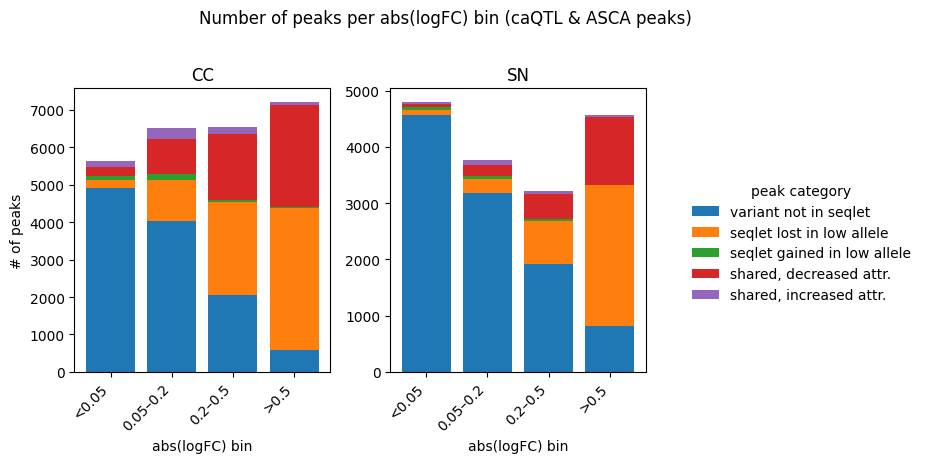

In [10]:

# ---- run count plot - adding peaks without seqlets ----
fig_counts = plot_peak_count_facets_by_bin(
    peakbin_tbl_newcats_full,
    title="Number of peaks per abs(logFC) bin (caQTL & ASCA peaks)",
)


# outpath = f"{outdir}/main/Figure4_peaks_with_variant_seqlets_by_bin_summary_num_peaks_full_peakset.pdf"
# fig_counts.savefig(outpath, dpi=300)

/tmp/ipykernel_1965107/4083735620.py:105: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["bin_pretty", "peak_variant_status"], as_index=False)
/tmp/ipykernel_1965107/4083735620.py:126: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  summ.pivot_table(


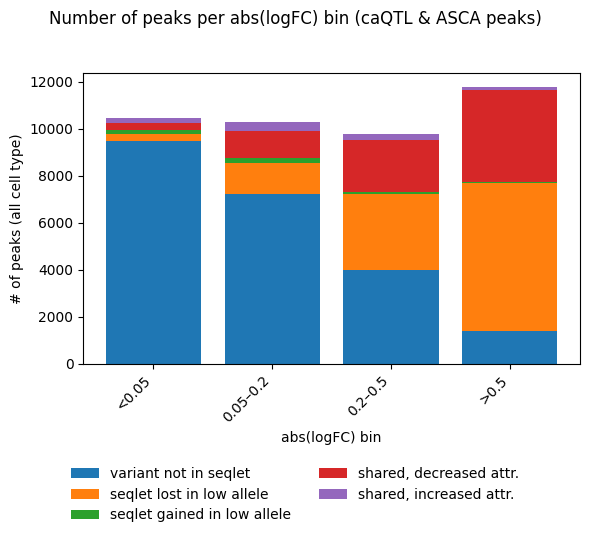

2026-03-07 23:21:56 | [INFO] maxp pruned
2026-03-07 23:21:56 | [INFO] cmap pruned
2026-03-07 23:21:56 | [INFO] kern dropped
2026-03-07 23:21:56 | [INFO] post pruned
2026-03-07 23:21:56 | [INFO] FFTM dropped
2026-03-07 23:21:56 | [INFO] GPOS pruned
2026-03-07 23:21:56 | [INFO] GSUB pruned
2026-03-07 23:21:56 | [INFO] glyf pruned
2026-03-07 23:21:56 | [INFO] Added gid0 to subset
2026-03-07 23:21:56 | [INFO] Added first four glyphs to subset
2026-03-07 23:21:56 | [INFO] Closing glyph list over 'MATH': 51 glyphs before
2026-03-07 23:21:56 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'C', 'F', 'L', 'N', 'Q', 'S', 'T', 'a', 'ampersand', 'b', 'c', 'comma', 'd', 'e', 'eight', 'endash', 'f', 'five', 'four', 'g', 'greater', 'h', 'i', 'k', 'l', 'less', 'm', 'n', 'nonmarkingreturn', 'numbersign', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'q', 'r', 's', 'six', 'space', 't', 'two', 'u', 'v', 'w', 'y', 'zero']
2026-03-07 23:21:56 | [INFO] Glyph IDs:   [0, 1, 2, 3, 6, 9, 11, 12, 15, 17,

In [28]:

# ---- run count plot - adding peaks without seqlets ----
fig_counts = plot_peak_count_by_bin(
    peakbin_tbl_newcats_full,
    title="Number of peaks per abs(logFC) bin (caQTL & ASCA peaks)",
)

outpath = f"{outdir}/main/Figure4_peaks_with_variant_seqlets_by_bin_summary_num_peaks_full_peakset_combined_legend.pdf"
fig_counts.savefig(outpath, dpi=300)

/tmp/ipykernel_2153517/1976416107.py:1974: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["bin_pretty", "peak_variant_status"], as_index=False)
/tmp/ipykernel_2153517/1976416107.py:1995: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  summ.pivot_table(


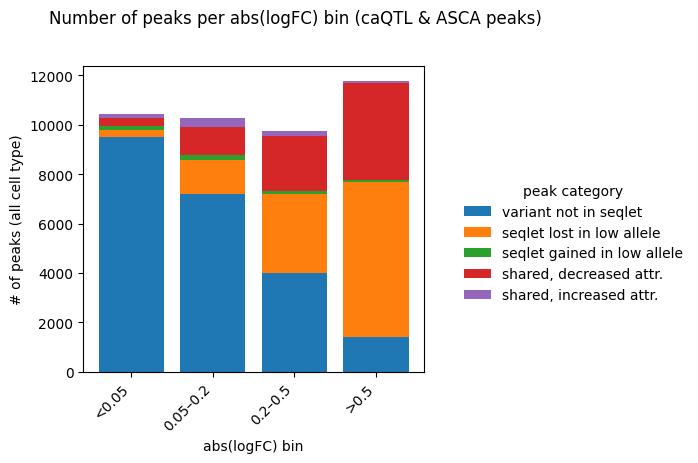

2026-03-02 15:58:37 | [INFO] maxp pruned
2026-03-02 15:58:37 | [INFO] cmap pruned
2026-03-02 15:58:37 | [INFO] kern dropped
2026-03-02 15:58:37 | [INFO] post pruned
2026-03-02 15:58:37 | [INFO] FFTM dropped
2026-03-02 15:58:37 | [INFO] GPOS pruned
2026-03-02 15:58:37 | [INFO] GSUB pruned
2026-03-02 15:58:37 | [INFO] glyf pruned
2026-03-02 15:58:37 | [INFO] Added gid0 to subset
2026-03-02 15:58:37 | [INFO] Added first four glyphs to subset
2026-03-02 15:58:37 | [INFO] Closing glyph list over 'MATH': 51 glyphs before
2026-03-02 15:58:37 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'C', 'F', 'L', 'N', 'Q', 'S', 'T', 'a', 'ampersand', 'b', 'c', 'comma', 'd', 'e', 'eight', 'endash', 'f', 'five', 'four', 'g', 'greater', 'h', 'i', 'k', 'l', 'less', 'm', 'n', 'nonmarkingreturn', 'numbersign', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'q', 'r', 's', 'six', 'space', 't', 'two', 'u', 'v', 'w', 'y', 'zero']
2026-03-02 15:58:37 | [INFO] Glyph IDs:   [0, 1, 2, 3, 6, 9, 11, 12, 15, 17,

In [23]:
# # same but before moving legend to bottom
# fig_counts = plot_peak_count_by_bin(
#     peakbin_tbl_newcats_full,
#     title="Number of peaks per abs(logFC) bin (caQTL & ASCA peaks)",
# )
# outpath = f"{outdir}/main/Figure4_peaks_with_variant_seqlets_by_bin_summary_num_peaks_full_peakset_combined.pdf"
# fig_counts.savefig(outpath, dpi=300)

# Figure 4F-J. tSNEs for disrupted motifs - currently fully independent code from above

## Setup and functions

In [2]:
import os
import time
import numpy as np
import polars as pl
import pandas as pd
import matplotlib 
import matplotlib.pyplot as plt
import seaborn as sns
import tfmindi as tm
import pickle

def log(msg):
    print(f"[{time.strftime('%Y-%m-%d %H:%M:%S')}] {msg}", flush=True)

WORKDIR = "/lustre1/project/stg_00090/ASA/analysis/analysis_Olga/3_T2T_analysis/12_TF_mindi_variants_caQTL_ASCA"
BASE = os.path.join(WORKDIR, "out_high_low_all_celltypes_v1_2")
outdir = "/staging/leuven/stg_00090/ASA/analysis/Manuscript/Figures/"


matplotlib.rcParams["pdf.fonttype"] = 42  # Use TrueType fonts instead of Type 3 fonts
matplotlib.rcParams["ps.fonttype"] = 42  # For PostScript as well, if needed

REGIONS = ["CC"] #, "SN"]

# Which merged files to use
H5AD_PATHS = {
    r: os.path.join(BASE, r, f"seqlets_{r}_combined_clustered.h5ad")
    for r in REGIONS
}

# column names (from your obs)
LOGFC_COL = "logfc"
SEQLET_START_COL = "start"
SEQLET_END_COL = "end"

# variant coordinate columns in obs (present in your data)
PEAK_START_COL = "REGION.START"
PEAK_END_COL = "REGION.END"
VAR_POS_COL = "TEST.SNP.POS"   # integer genomic position

# coordinate-system constants
PEAK_LEN = 500
MODEL_LEN = 2114
PEAK_CENTER = PEAK_LEN // 2           # 250
MODEL_CENTER = MODEL_LEN // 2         # 1057

# bins for abs(logfc)
BINS = [
    ("abslogfc_lt_0p05", None, 0.05),
    ("abslogfc_0p05_0p2", 0.05, 0.2),
    ("abslogfc_0p2_0p5", 0.2, 0.5),
    ("abslogfc_gt_0p5", 0.5, None),
]


In [3]:
CLUSTER_COL = "leiden"
OH_COL = "example_oh"
CONTRIB_COL = "example_contrib"


def abslogfc_bin_expr(col=LOGFC_COL):
    """
    Returns a Polars expression that bins abs(logfc) into named bins above.
    """
    a = pl.col(col).abs()
    expr = None

    for name, lo, hi in BINS:
        cond = pl.lit(True)
        if lo is not None:
            cond &= (a >= lo)
        if hi is not None:
            cond &= (a < hi)

        if expr is None:
            expr = pl.when(cond).then(pl.lit(name))
        else:
            expr = expr.when(cond).then(pl.lit(name))

    return expr.otherwise(pl.lit("abslogfc_nan_or_outside"))


def add_variant_in_seqlet(df: pl.DataFrame) -> pl.DataFrame:
    """
    Add:
      - var_in_2114 (variant position in 2114 window coords)
      - variant_in_seqlet (boolean)

    Uses:
      var_in_peak = TEST.SNP.POS - REGION.START
      var_in_2114 = var_in_peak - PEAK_CENTER + MODEL_CENTER
      variant_in_seqlet = start <= var_in_2114 < end
    """
    required = [SEQLET_START_COL, SEQLET_END_COL, PEAK_START_COL, VAR_POS_COL]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns for variant mapping: {missing}")

    df2 = df.with_columns([
        (pl.col(VAR_POS_COL).cast(pl.Int64) - pl.col(PEAK_START_COL).cast(pl.Int64)).alias("var_in_peak"),
    ]).with_columns([
        (pl.col("var_in_peak") - pl.lit(PEAK_CENTER) + pl.lit(MODEL_CENTER)).alias("var_in_2114"),
    ]).with_columns([
        (
            (pl.col("var_in_2114") >= pl.col(SEQLET_START_COL)) &
            (pl.col("var_in_2114") < pl.col(SEQLET_END_COL))
        ).alias("variant_in_seqlet")
    ])

    return df2


def summarize_bins_for_region(df: pl.DataFrame, region: str) -> pl.DataFrame:
    """
    Aggregate across all cell types:
      group by abslogfc_bin and variant_in_seqlet -> count seqlets
    """
    if "abslogfc_bin" not in df.columns:
        raise ValueError("df missing 'abslogfc_bin'")
    if "variant_in_seqlet" not in df.columns:
        raise ValueError("df missing 'variant_in_seqlet'")

    out = (
        df.group_by(["abslogfc_bin", "variant_in_seqlet"])
          .len()
          .rename({"len": "n_seqlets"})
          .with_columns(pl.lit(region).alias("brain_region"))
    )
    return out




def _first_ndarray(series):
    arr = series.to_numpy()
    for x in arr:
        if isinstance(x, np.ndarray):
            return x
    return None

def _transpose_if_L4(x, model_len=MODEL_LEN):
    """
    Ensure per-row matrix is (4, L). Accepts (L,4) and transposes.
    Returns (x_fixed, ok_bool).
    """
    if not isinstance(x, np.ndarray) or x.ndim != 2:
        return x, False

    # already (4, L)
    if x.shape[0] == 4:
        return x, True

    # (L, 4) -> transpose
    if x.shape[1] == 4:
        return x.T, True

    # unknown shape
    return x, False

def subsample_indices_per_cluster(adata, by=CLUSTER_COL, max_n=1000, seed=0):
    rng = np.random.default_rng(seed)
    clusters = adata.obs[by].astype(str).to_numpy()
    uniq = np.unique(clusters)

    keep = []
    for c in uniq:
        idx = np.where(clusters == c)[0]
        if len(idx) == 0:
            continue
        if max_n is not None and len(idx) > max_n:
            idx = rng.choice(idx, size=max_n, replace=False)
        keep.append(idx)
    keep = np.concatenate(keep) if keep else np.array([], dtype=int)
    return keep

def prepare_adata_for_patterns(adata, max_n=1000, seed=0,
                              by=CLUSTER_COL,
                              oh_col=OH_COL, contrib_col=CONTRIB_COL,
                              start_col=SEQLET_START_COL, end_col=SEQLET_END_COL,
                              model_len=MODEL_LEN):
    # 1) subsample per cluster
    keep_idx = subsample_indices_per_cluster(adata, by=by, max_n=max_n, seed=seed)
    log(f"Subsampled to {len(keep_idx):,} seqlets (~{max_n} per cluster) for pattern calling")
    ad = adata[keep_idx].copy()

    # 2) transpose example_oh / example_contrib elementwise if needed
    for col in [oh_col, contrib_col]:
        if col not in ad.obs.columns:
            raise KeyError(f"Missing obs column: {col}")

        ex = _first_ndarray(ad.obs[col])
        log(f"Sample {col} element shape before: {None if ex is None else ex.shape}")

        vals = ad.obs[col].to_numpy()
        new_vals = np.empty_like(vals, dtype=object)
        ok = np.zeros(len(vals), dtype=bool)

        for i, x in enumerate(vals):
            x2, ok_i = _transpose_if_L4(x, model_len=model_len)
            new_vals[i] = x2
            ok[i] = ok_i

        ad.obs[col] = new_vals
        log(f"  {col}: transposed/validated {ok.sum():,} / {len(ok):,} rows")

    # 3) filter rows where matrices don’t cover end (or malformed)
    starts = ad.obs[start_col].to_numpy(dtype=int)
    ends = ad.obs[end_col].to_numpy(dtype=int)

    oh_vals = ad.obs[oh_col].to_numpy()
    contrib_vals = ad.obs[contrib_col].to_numpy()

    good = np.ones(ad.n_obs, dtype=bool)

    for i in range(ad.n_obs):
        oh = oh_vals[i]
        cb = contrib_vals[i]
        if (not isinstance(oh, np.ndarray)) or (not isinstance(cb, np.ndarray)):
            good[i] = False
            continue
        # must be (4, L)
        if oh.ndim != 2 or cb.ndim != 2 or oh.shape[0] != 4 or cb.shape[0] != 4:
            good[i] = False
            continue
        # must be long enough for the seqlet end coordinate
        if ends[i] > oh.shape[1] or ends[i] > cb.shape[1] or starts[i] < 0 or ends[i] <= starts[i]:
            good[i] = False
            continue

    n_bad = int((~good).sum())
    log(f"Filtering malformed/out-of-bounds matrices: dropping {n_bad:,} / {ad.n_obs:,}")
    ad = ad[good].copy()

    # sanity
    ex_oh = _first_ndarray(ad.obs[oh_col])
    ex_cb = _first_ndarray(ad.obs[contrib_col])
    log(f"Sample {oh_col} element shape after: {None if ex_oh is None else ex_oh.shape}")
    log(f"Sample {contrib_col} element shape after: {None if ex_cb is None else ex_cb.shape}")

    return ad


## Load data

In [4]:
adatas = {}

for region in REGIONS:
    path = H5AD_PATHS[region]
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing: {path}")

    log(f"Loading merged clustered adata for {region}: {path}")
    adata = tm.load_h5ad(path)
    adata.obs["cluster_dbd"] = adata.obs["cluster_dbd"].astype("object").fillna("Unknown")


    # Optional but recommended: avoid obs-name collisions downstream
    # (doesn't change biological content; just makes indices unique)
    if not adata.obs_names.is_unique:
        log(f"  [WARN] {region}: obs_names not unique -> making unique")
        adata.obs_names_make_unique()

    log(f"  n_obs={adata.n_obs:,} n_vars={adata.n_vars:,}")
    adatas[region] = adata

log(f"Loaded regions: {list(adatas.keys())}")


[2026-03-08 12:12:35] Loading merged clustered adata for CC: /lustre1/project/stg_00090/ASA/analysis/analysis_Olga/3_T2T_analysis/12_TF_mindi_variants_caQTL_ASCA/out_high_low_all_celltypes_v1_2/CC/seqlets_CC_combined_clustered.h5ad


[2026-03-08 12:13:07]   n_obs=517,907 n_vars=3,989
[2026-03-08 12:13:07] Loaded regions: ['CC']


In [5]:
out_path = os.path.join(
    WORKDIR, "out_high_low_all_celltypes_v1_2", "CC", "tf_mindi_patterns_cc.pkl"
)

with open(out_path, "rb") as f:
    patterns_cc = pickle.load(f)

## seqlet annotations

In [6]:
def abslogfc_bin_expr(
    col: str = "logfc",
    *,
    breakpoints: list[float] = (0.05, 0.2, 0.5),
    labels: list[str] = (
        "abslogfc_lt_0p05",
        "abslogfc_0p05_0p2",
        "abslogfc_0p2_0p5",
        "abslogfc_gt_0p5",
    ),
    fallback_label: str = "abslogfc_nan_or_outside",
) -> pl.Expr:
    """
    Bin abs(col) into intervals using Polars `cut`.

    Intervals are:
      (-inf, b0), [b0, b1), [b1, b2), ..., [b_{k-1}, inf)

    Nulls (and anything not binned) become `fallback_label`.
    """
    if len(labels) != len(breakpoints) + 1:
        raise ValueError("`labels` must have exactly len(breakpoints) + 1 elements.")

    a = pl.col(col).abs()

    # Prefer left-closed/right-open bins (i.e. [lo, hi)) when supported by your Polars version.
    try:
        binned = a.cut(breaks=list(breakpoints), labels=list(labels), left_closed=True)
    except TypeError:
        # Fallback for older Polars: emulate [lo, hi) using right-closed cut
        # by nudging breakpoints slightly upward (so exact boundary goes to the higher bin).
        eps = 1e-12
        shifted = [b + eps for b in breakpoints]
        binned = a.cut(breaks=shifted, labels=list(labels))

    return binned.fill_null(fallback_label)



def add_variant_in_seqlet(
    df: pl.DataFrame,
    *,
    # column names (match your obs defaults)
    seqlet_start_col: str = "start",          # SEQLET_START_COL
    seqlet_end_col: str = "end",              # SEQLET_END_COL
    peak_start_col: str = "REGION.START",     # PEAK_START_COL
    var_pos_col: str = "TEST.SNP.POS",        # VAR_POS_COL
    # coordinate-system constants (defaults match your values)
    peak_len: int = 500,                      # PEAK_LEN
    model_len: int = 2114,                    # MODEL_LEN
    # output columns
    var_in_peak_col: str = "var_in_peak",
    var_in_model_col: str = "var_in_2114",
    variant_in_seqlet_col: str = "variant_in_seqlet",
) -> pl.DataFrame:
    """
    Adds:
      - var_in_peak:   var_pos - peak_start
      - var_in_model:  var_in_peak - (peak_len//2) + (model_len//2)
      - variant_in_seqlet: seqlet_start <= var_in_model < seqlet_end
    """
    required = [seqlet_start_col, seqlet_end_col, peak_start_col, var_pos_col]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns for variant mapping: {missing}")

    peak_center = peak_len // 2
    model_center = model_len // 2

    return df.with_columns(
                (pl.col(var_pos_col).cast(pl.Int64) - pl.col(peak_start_col).cast(pl.Int64)).alias(var_in_peak_col)
            ).with_columns(
                (pl.col(var_in_peak_col) - pl.lit(peak_center) + pl.lit(model_center)).alias(var_in_model_col)
            ).with_columns(
                 ((pl.col(var_in_model_col) >= pl.col(seqlet_start_col)) & (pl.col(var_in_model_col) < pl.col(seqlet_end_col))).alias(variant_in_seqlet_col),
            )   
    



def add_overlap_status_by_interval_overlap(
    df: pl.DataFrame,
    group_cols=("brain_region", "cell_type", "peak_id"),
    allele_col="allele",
    start_col=SEQLET_START_COL,
    end_col=SEQLET_END_COL,
    high_label="high_allele",
    low_label="low_allele",
    min_overlap_bp: int = 1,
    status_col: str = "overlap_status",   # shared / high_only / low_only
) -> pl.DataFrame:
    """
    Add `status_col` to df:
      - 'shared' if seqlet overlaps any seqlet from the other allele within the same group
      - 'high_only' / 'low_only' otherwise

    Overlap is defined as intersection length >= min_overlap_bp on [start, end) intervals.
    Grouping is done per `group_cols`.
    """
    needed = list(group_cols) + [allele_col, start_col, end_col]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns for overlap labeling: {missing}")

    # Keep stable row mapping
    df2 = df.with_row_index("_row_id")

    status = np.empty(df2.height, dtype=object)

    # Partition by group; maintain order for reproducibility
    parts = df2.partition_by(list(group_cols), as_dict=True, maintain_order=True)

    for _, g in parts.items():
        row_ids = g["_row_id"].to_numpy()

        alleles = g[allele_col].to_numpy()
        s = g[start_col].to_numpy()
        e = g[end_col].to_numpy()

        # valid coords (non-null)
        valid = (s != None) & (e != None)
        # default if invalid coords: treat as allele-specific later
        # (still gets set below based on allele)
        s_valid = np.where(valid, s, 0).astype(np.int64, copy=False)
        e_valid = np.where(valid, e, 0).astype(np.int64, copy=False)

        is_high = (alleles == high_label) & valid
        is_low  = (alleles == low_label) & valid

        # initialize within-group with allele-only defaults
        grp_status = np.full(g.height, None, dtype=object)
        grp_status[alleles == high_label] = "high_only"
        grp_status[alleles == low_label]  = "low_only"

        # if one side absent -> done
        if is_high.sum() == 0 or is_low.sum() == 0:
            status[row_ids] = grp_status
            continue

        # extract + sort by start
        hi_idx = np.flatnonzero(is_high)
        lo_idx = np.flatnonzero(is_low)

        h_s = s_valid[hi_idx]
        h_e = e_valid[hi_idx]
        l_s = s_valid[lo_idx]
        l_e = e_valid[lo_idx]

        h_ord = np.argsort(h_s, kind="mergesort")
        l_ord = np.argsort(l_s, kind="mergesort")

        hi_idx = hi_idx[h_ord]
        lo_idx = lo_idx[l_ord]
        h_s, h_e = h_s[h_ord], h_e[h_ord]
        l_s, l_e = l_s[l_ord], l_e[l_ord]

        h_match = np.zeros(len(hi_idx), dtype=bool)
        l_match = np.zeros(len(lo_idx), dtype=bool)

        # two-pointer sweep on half-open intervals [start, end)
        i = j = 0
        while i < len(hi_idx) and j < len(lo_idx):
            lo = max(h_s[i], l_s[j])
            hi = min(h_e[i], l_e[j])
            if (hi - lo) >= min_overlap_bp:
                h_match[i] = True
                l_match[j] = True

            if h_e[i] <= l_e[j]:
                i += 1
            else:
                j += 1

        # apply shared labels
        grp_status[hi_idx[h_match]] = "shared"
        grp_status[lo_idx[l_match]] = "shared"

        status[row_ids] = grp_status

    # attach and clean up
    out = df2.with_columns(pl.Series(status_col, status).cast(pl.Utf8)).drop("_row_id")
    return out


In [7]:
region = "CC"
adata_cc = adatas[region]  # use preloaded


# column names (from your obs)
LOGFC_COL = "logfc"
SEQLET_START_COL = "start"
SEQLET_END_COL = "end"

# variant coordinate columns in obs (present in your data)
PEAK_START_COL = "REGION.START"
PEAK_END_COL = "REGION.END"
VAR_POS_COL = "TEST.SNP.POS"   # integer genomic position

# coordinate-system constants
PEAK_LEN = 500
MODEL_LEN = 2114
PEAK_CENTER = PEAK_LEN // 2           # 250
MODEL_CENTER = MODEL_LEN // 2         # 1057

# remove columns contining arrays
obs = adata.obs.copy()
df = pl.from_pandas(obs.drop(columns = ['seqlet_matrix', 'seqlet_oh']))

# Add bins + variant overlap
df = df.with_columns([
    abslogfc_bin_expr(LOGFC_COL).alias("abslogfc_bin")
])
df = add_variant_in_seqlet(df)

# # NEW: add overlap_status (shared/high_only/low_only) via interval overlap
df = add_overlap_status_by_interval_overlap(
    df,
    group_cols=("brain_region", "cell_type", "peak_id"),
    allele_col="allele",
    start_col=SEQLET_START_COL,
    end_col=SEQLET_END_COL,
    high_label="high_allele",
    low_label="low_allele",
    min_overlap_bp=1,
    status_col="overlap_status",
)


In [8]:
# update adata.obs with new columns
adata_cc.obs = df.to_pandas()

/lustre1/project/stg_00002/mambaforge/vsc35059/envs/tfmindi_160126_gpu/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [9]:
import numpy as np
import matplotlib.colors as mcolors
from matplotlib import cm

col = "cluster_dbd"

def _blend_with_white(rgb, amount=0.18):
    rgb = np.asarray(rgb, dtype=float)
    return rgb * (1 - amount) + np.array([1, 1, 1]) * amount

def make_set3_extended(n, *, pastelize=0.18, seed=0):
    """
    Extend Set3 to n colors while staying Set3-like:
    - take Set3 base
    - add new colors by interpolating between base colors (in RGB)
    - greedily select maximally separated colors from the candidate pool
    """
    if n <= 0:
        return []

    rng = np.random.default_rng(seed)

    # Base Set3 (12)
    base = [mcolors.to_rgb(c) for c in cm.get_cmap("Set3", 12).colors]
    base = np.array([_blend_with_white(c, amount=pastelize) for c in base])

    if n <= len(base):
        return [mcolors.to_hex(c) for c in base[:n]]

    # Build a candidate pool: base + many interpolations between pairs
    cand = [*base]

    # interpolate between random pairs (keeps Set3 character)
    n_interp = max(200, 40 * n)  # plenty of candidates
    idx_i = rng.integers(0, len(base), size=n_interp)
    idx_j = rng.integers(0, len(base), size=n_interp)
    t = rng.uniform(0.25, 0.75, size=n_interp)  # avoid too-close-to-endpoints

    interp = base[idx_i] * (1 - t[:, None]) + base[idx_j] * (t[:, None])
    interp = np.array([_blend_with_white(c, amount=pastelize) for c in interp])
    cand.extend(interp)

    cand = np.clip(np.array(cand), 0, 1)

    # Greedy max–min selection for separation
    chosen = [cand[0]]
    dists = np.linalg.norm(cand - chosen[0], axis=1)

    for _ in range(1, n):
        j = int(np.argmax(dists))
        chosen.append(cand[j])
        new_d = np.linalg.norm(cand - cand[j], axis=1)
        dists = np.minimum(dists, new_d)

    return [mcolors.to_hex(c) for c in chosen[:n]]

# categories for colors
vals = adata_cc.obs[col].astype("category")
cats = list(vals.cat.categories)

cats_no_unknown = [c for c in cats if str(c).strip().lower() != "unknown"]

# ~Set3-like but extended (e.g., ~20 colors)
palette = make_set3_extended(len(cats_no_unknown), pastelize=0.12, seed=1)

color_map = {}
i = 0
for c in cats:
    if str(c).strip().lower() == "unknown":
        color_map[c] = "#BDBDBD"  # grey
    else:
        color_map[c] = palette[i]
        i += 1


# --- swap colors for two labels ---
a, b = "C2H2 ZF", "Homeodomain"
if a in color_map and b in color_map:
    color_map[a], color_map[b] = color_map[b], color_map[a]
else:
    print("Swap skipped; missing:", [x for x in (a, b) if x not in color_map])


# --- swap colors for two labels ---
a, b = "HMG/Sox", "Rel"
if a in color_map and b in color_map:
    color_map[a], color_map[b] = color_map[b], color_map[a]
else:
    print("Swap skipped; missing:", [x for x in (a, b) if x not in color_map])


adata_cc.uns[f"{col}_colors"] = color_map  # tfmindi expects dict


/tmp/ipykernel_2027977/3017488464.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = [mcolors.to_rgb(c) for c in cm.get_cmap("Set3", 12).colors]


## Figure 4F-J. seqlet tSNEs

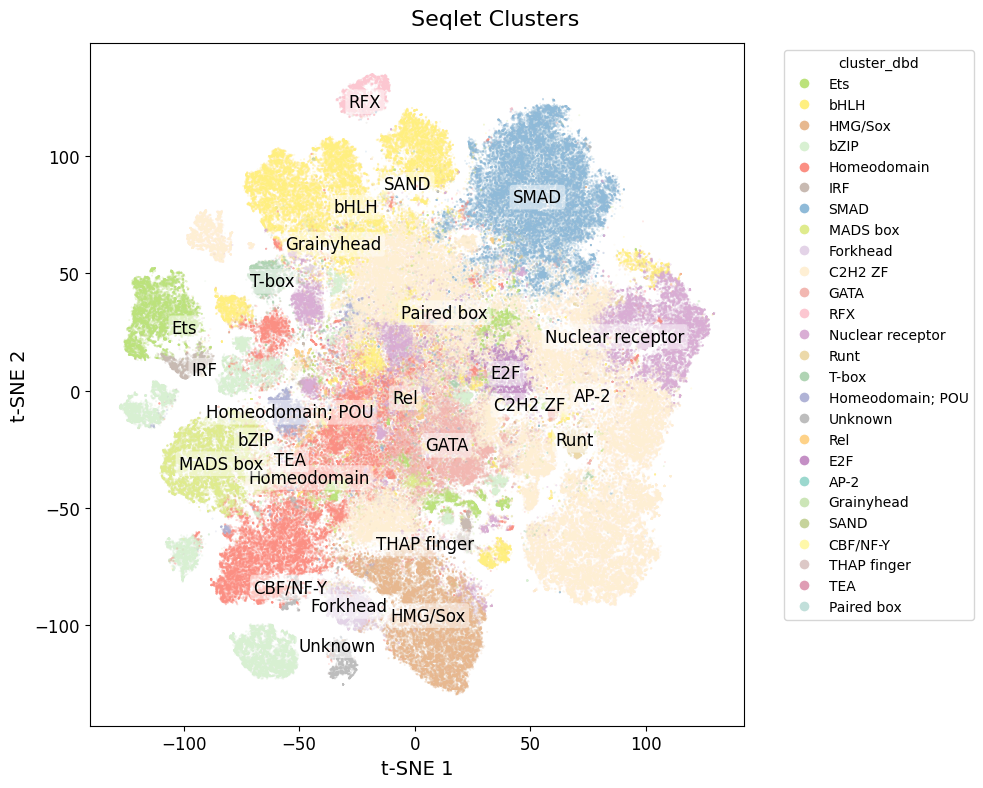

In [10]:
# # Categories in stable order
# vals = adata_cc.obs[col].astype("category")
# cats = list(vals.cat.categories)
# n = len(cats) 

# # Build palette + map categories -> colors (THIS is what tfmindi expects)
# palette = make_more_set3_like(n)
# adata_cc.uns[f"{col}_colors"] = {cat: palette[i] for i, cat in enumerate(cats)}

fig = tm.pl.tsne(
    adata_cc,
    color_by="cluster_dbd",
    show=False,
    width=10,
    height=8,
    s=0.1,
    alpha=0.3,
    show_legend=True,
)

# ---- your labeling code unchanged ----
ax = fig.axes[0]
X = adata_cc.obsm["X_tsne"]
vals = adata_cc.obs[col].astype("category")

for cat in vals.cat.categories:
    m = (vals == cat).to_numpy()
    if not m.any():
        continue
    x, y = np.median(X[m, 0]), np.median(X[m, 1])
    ax.text(
        x, y, str(cat),
        ha="center", va="center",
        fontsize=12,
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.5, linewidth=0),
        zorder=10,
    )

In [11]:
outdir = "/staging/leuven/stg_00090/ASA/analysis/Manuscript/Figures"

# # rasterize scatter in main axes but NOT in legend axes
# for ax in fig.axes:
#     if ax.get_legend():   # <- if this axes has a legend, skip it
#         continue
#     for artist in ax.collections:
#         artist.set_rasterized(True)

# fig.savefig(f"{outdir}/main/Fig4F_TF_mindi_dbd_tSNE.pdf", dpi=300)

ax = fig.axes[0]  # main tSNE axes
for coll in ax.collections:
    coll.set_rasterized(True)

fig.savefig(f"{outdir}/main/Fig4F_TF_mindi_dbd_tSNE.pdf", dpi=300)

2026-03-07 22:23:41 | [INFO] maxp pruned
2026-03-07 22:23:41 | [INFO] cmap pruned
2026-03-07 22:23:41 | [INFO] kern dropped
2026-03-07 22:23:41 | [INFO] post pruned
2026-03-07 22:23:41 | [INFO] FFTM dropped
2026-03-07 22:23:41 | [INFO] GPOS pruned
2026-03-07 22:23:41 | [INFO] GSUB pruned
2026-03-07 22:23:41 | [INFO] glyf pruned
2026-03-07 22:23:41 | [INFO] Added gid0 to subset
2026-03-07 22:23:41 | [INFO] Added first four glyphs to subset
2026-03-07 22:23:41 | [INFO] Closing glyph list over 'MATH': 57 glyphs before
2026-03-07 22:23:41 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'five', 'g', 'h', 'hyphen', 'i', 'k', 'l', 'm', 'minus', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'q', 'r', 's', 'semicolon', 'slash', 'space', 't', 'two', 'u', 'underscore', 'w', 'x', 'y', 'zero']
2026-03-07 22:23:41 | [INFO] Glyph IDs:   [0, 1, 2, 3, 16, 18, 19, 20, 21, 24, 30,

Oligo: selected 45716 cells
  False: 43294, True: 2422


2026-03-08 12:35:21 | [INFO] maxp pruned
2026-03-08 12:35:21 | [INFO] cmap pruned
2026-03-08 12:35:21 | [INFO] kern dropped
2026-03-08 12:35:21 | [INFO] post pruned
2026-03-08 12:35:21 | [INFO] FFTM dropped
2026-03-08 12:35:21 | [INFO] GPOS pruned
2026-03-08 12:35:21 | [INFO] GSUB pruned
2026-03-08 12:35:21 | [INFO] glyf pruned
2026-03-08 12:35:21 | [INFO] Added gid0 to subset
2026-03-08 12:35:21 | [INFO] Added first four glyphs to subset
2026-03-08 12:35:21 | [INFO] Closing glyph list over 'MATH': 30 glyphs before
2026-03-08 12:35:21 | [INFO] Glyph names: ['.notdef', '.null', 'E', 'F', 'N', 'O', 'S', 'T', 'a', 'e', 'five', 'g', 'hyphen', 'i', 'l', 'minus', 'n', 'nonmarkingreturn', 'o', 'one', 'q', 'r', 's', 'space', 't', 'two', 'u', 'underscore', 'v', 'zero']
2026-03-08 12:35:21 | [INFO] Glyph IDs:   [0, 1, 2, 3, 16, 19, 20, 21, 24, 40, 41, 49, 50, 54, 55, 66, 68, 72, 74, 76, 79, 81, 82, 84, 85, 86, 87, 88, 89, 3228]
2026-03-08 12:35:21 | [INFO] Closed glyph list over 'MATH': 30 glyph

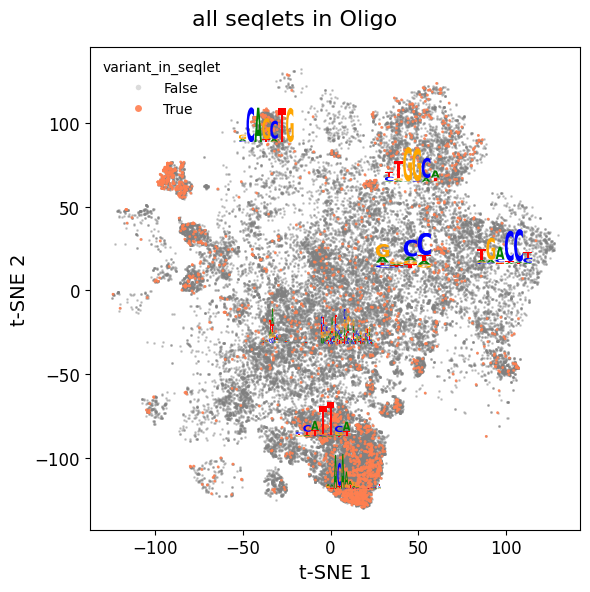

Micro-PVM: selected 47071 cells
  False: 44568, True: 2503


2026-03-08 12:35:25 | [INFO] maxp pruned
2026-03-08 12:35:25 | [INFO] cmap pruned
2026-03-08 12:35:25 | [INFO] kern dropped
2026-03-08 12:35:25 | [INFO] post pruned
2026-03-08 12:35:25 | [INFO] FFTM dropped
2026-03-08 12:35:25 | [INFO] GPOS pruned
2026-03-08 12:35:25 | [INFO] GSUB pruned
2026-03-08 12:35:25 | [INFO] glyf pruned
2026-03-08 12:35:25 | [INFO] Added gid0 to subset
2026-03-08 12:35:25 | [INFO] Added first four glyphs to subset
2026-03-08 12:35:25 | [INFO] Closing glyph list over 'MATH': 32 glyphs before
2026-03-08 12:35:25 | [INFO] Glyph names: ['.notdef', '.null', 'E', 'F', 'M', 'N', 'P', 'S', 'T', 'V', 'a', 'c', 'e', 'five', 'hyphen', 'i', 'l', 'minus', 'n', 'nonmarkingreturn', 'o', 'one', 'q', 'r', 's', 'space', 't', 'two', 'u', 'underscore', 'v', 'zero']
2026-03-08 12:35:25 | [INFO] Glyph IDs:   [0, 1, 2, 3, 16, 19, 20, 21, 24, 40, 41, 48, 49, 51, 54, 55, 57, 66, 68, 70, 72, 76, 79, 81, 82, 84, 85, 86, 87, 88, 89, 3228]
2026-03-08 12:35:25 | [INFO] Closed glyph list ove

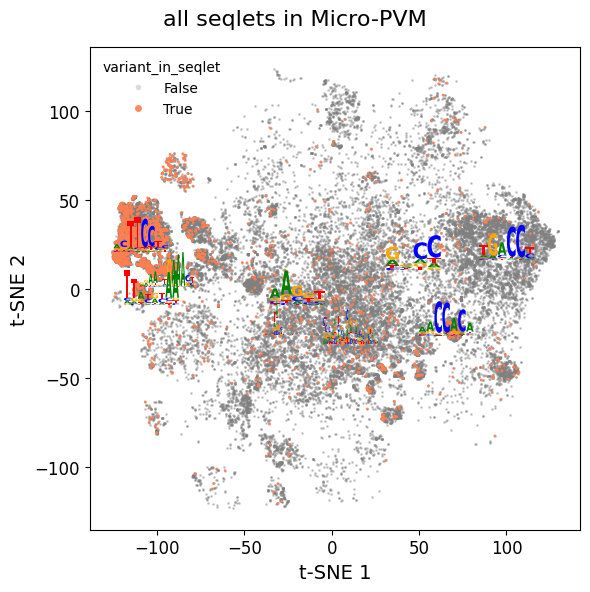

Astro: selected 53324 cells
  False: 50736, True: 2588


2026-03-08 12:35:30 | [INFO] maxp pruned
2026-03-08 12:35:30 | [INFO] cmap pruned
2026-03-08 12:35:30 | [INFO] kern dropped
2026-03-08 12:35:30 | [INFO] post pruned
2026-03-08 12:35:30 | [INFO] FFTM dropped
2026-03-08 12:35:30 | [INFO] GPOS pruned
2026-03-08 12:35:30 | [INFO] GSUB pruned
2026-03-08 12:35:30 | [INFO] glyf pruned
2026-03-08 12:35:30 | [INFO] Added gid0 to subset
2026-03-08 12:35:30 | [INFO] Added first four glyphs to subset
2026-03-08 12:35:30 | [INFO] Closing glyph list over 'MATH': 29 glyphs before
2026-03-08 12:35:30 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'E', 'F', 'N', 'S', 'T', 'a', 'e', 'five', 'hyphen', 'i', 'l', 'minus', 'n', 'nonmarkingreturn', 'o', 'one', 'q', 'r', 's', 'space', 't', 'two', 'u', 'underscore', 'v', 'zero']
2026-03-08 12:35:30 | [INFO] Glyph IDs:   [0, 1, 2, 3, 16, 19, 20, 21, 24, 36, 40, 41, 49, 54, 55, 66, 68, 72, 76, 79, 81, 82, 84, 85, 86, 87, 88, 89, 3228]
2026-03-08 12:35:30 | [INFO] Closed glyph list over 'MATH': 29 glyphs after
2

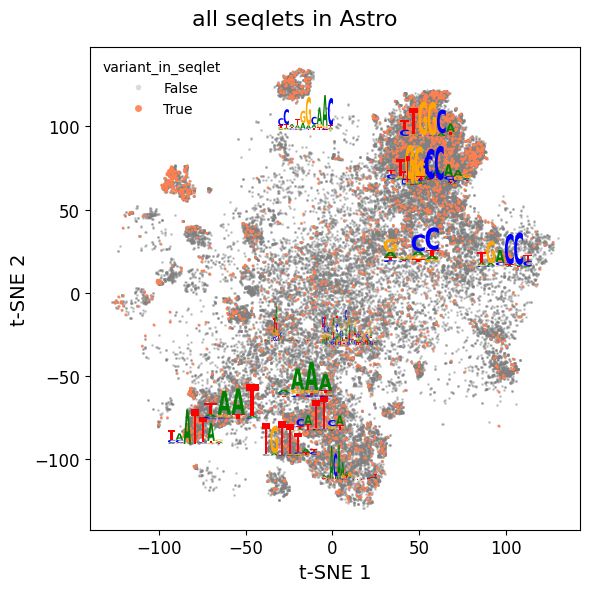

L2_3_IT: selected 160017 cells
  False: 153159, True: 6858


2026-03-08 12:35:42 | [INFO] maxp pruned
2026-03-08 12:35:42 | [INFO] cmap pruned
2026-03-08 12:35:42 | [INFO] kern dropped
2026-03-08 12:35:42 | [INFO] post pruned
2026-03-08 12:35:42 | [INFO] FFTM dropped
2026-03-08 12:35:42 | [INFO] GPOS pruned
2026-03-08 12:35:42 | [INFO] GSUB pruned
2026-03-08 12:35:42 | [INFO] glyf pruned
2026-03-08 12:35:42 | [INFO] Added gid0 to subset
2026-03-08 12:35:42 | [INFO] Added first four glyphs to subset
2026-03-08 12:35:42 | [INFO] Closing glyph list over 'MATH': 30 glyphs before
2026-03-08 12:35:42 | [INFO] Glyph names: ['.notdef', '.null', 'E', 'F', 'I', 'L', 'N', 'S', 'T', 'a', 'e', 'five', 'hyphen', 'i', 'l', 'minus', 'n', 'nonmarkingreturn', 'one', 'q', 'r', 's', 'space', 't', 'three', 'two', 'u', 'underscore', 'v', 'zero']
2026-03-08 12:35:42 | [INFO] Glyph IDs:   [0, 1, 2, 3, 16, 19, 20, 21, 22, 24, 40, 41, 44, 47, 49, 54, 55, 66, 68, 72, 76, 79, 81, 84, 85, 86, 87, 88, 89, 3228]
2026-03-08 12:35:42 | [INFO] Closed glyph list over 'MATH': 30 g

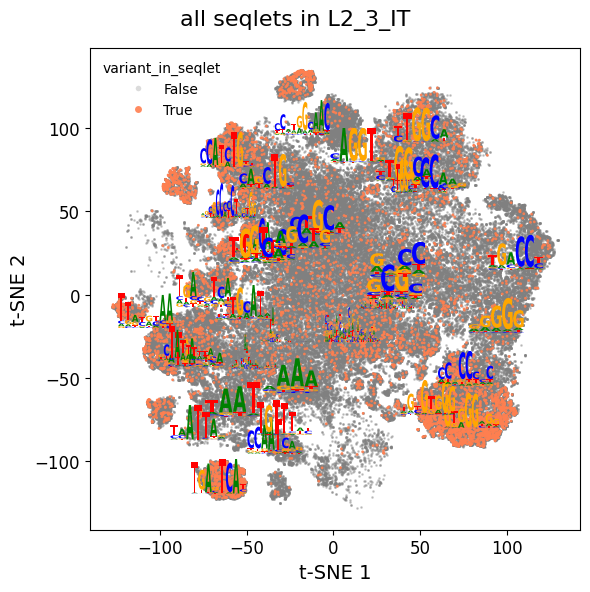

In [11]:
import os
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

CLUSTER_COL = "leiden"
VARIANT_COL = "variant_in_seqlet"

for cell_type in ["Oligo", "Micro-PVM", "Astro", "L2_3_IT"]:

    # --- select cells robustly ---
    mask = (adata_cc.obs["cell_type"] == cell_type)
    idx = np.flatnonzero(mask.to_numpy())
    print(f"{cell_type}: selected {len(idx)} cells")

    if len(idx) == 0:
        print(f"Skipping {cell_type}: no cells matched.")
        continue

    # --- create subset copy WITHOUT obsp/varp ---
    view = adata_cc[idx, :]

    adata_cc_subset = ad.AnnData(
        X=view.X.copy(),
        obs=view.obs.copy(),
        var=view.var.copy(),
        obsm={k: v.copy() for k, v in view.obsm.items()},
        varm={k: v.copy() for k, v in view.varm.items()},
        uns=dict(view.uns),
    )

    for k, v in view.layers.items():
        adata_cc_subset.layers[k] = v.copy()

    # IMPORTANT: remove any color mapping that could recolor points
    for k in list(adata_cc_subset.uns.keys()):
        if k.endswith("_colors"):
            del adata_cc_subset.uns[k]

    # --- major clusters (>1000) for this subset ---
    counts = adata_cc_subset.obs[CLUSTER_COL].astype(str).value_counts()
    keep_clusters = set(counts[counts > 1000].index.tolist())
    patterns_plot = {str(k): v for k, v in patterns_cc.items() if str(k) in keep_clusters}

    # --- split True / False ---
    mask_true = adata_cc_subset.obs[VARIANT_COL].fillna(False).astype(bool).to_numpy()
    n_true = int(mask_true.sum())
    n_false = int((~mask_true).sum())
    print(f"  False: {n_false}, True: {n_true}")

    # --- base plot: all points in grey, logos drawn once ---
    fig = tm.pl.tsne_logos(
        adata_cc_subset,
        patterns=patterns_plot if len(patterns_plot) else None,
        s=1,                 # small base dots
        alpha=0.35,          # faint base dots
        show_legend=False,
        gray_background=True,   # <-- this is the key fix
        logo_width=0.55,
        logo_height=0.35,
        ic_threshold=0.2,
        min_nucleotides=4,
        show_cluster_labels=False,
        width=6,
        height=6,
        title=f"all seqlets in {cell_type}",
        show=False,
        dpi=200,
    )

    ax = fig.axes[0]

    # --- overlay True on top in coral ---
    if n_true > 0:
        tsne = adata_cc_subset.obsm["X_tsne"]
        x_true = tsne[mask_true, 0]
        y_true = tsne[mask_true, 1]

        ax.scatter(
            x_true,
            y_true,
            c="coral",
            s=4,           # slightly larger than background
            alpha=0.9,
            edgecolors="none",
            zorder=10,     # ensure True is on top
        )

    # --- manual legend ---
    handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            markerfacecolor="lightgrey",
            markeredgecolor="none",
            markersize=4,
            alpha=0.8,
            label="False",
        ),
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            markerfacecolor="coral",
            markeredgecolor="none",
            markersize=5,
            alpha=0.9,
            label="True",
        ),
    ]
    ax.legend(handles=handles, title=VARIANT_COL, loc="best", frameon=False)


    ax = fig.axes[0]  # main tSNE axes
    for coll in ax.collections:
        coll.set_rasterized(True)

    fname = f"CC_tsne_logos_{cell_type}".replace("/", "_").replace(" ", "_")
    fig.savefig(f"{outdir}/main/Figure4_{fname}.pdf", dpi=300)


    plt.show()
    plt.close(fig)

In [12]:
outdir

'/staging/leuven/stg_00090/ASA/analysis/Manuscript/Figures/'